# Imports

In [1]:
# from logit_model import *
import statsmodels.api as sm
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
from statsmodels.stats.outliers_influence import variance_inflation_factor




In [2]:
import seaborn as sns
import sys
import os

# Add parent directory to sys.path
parent_dir = os.path.abspath(os.path.join(os.getcwd(), os.pardir))
sys.path.append(parent_dir)


In [3]:
from package_files.benefits_defns import *

In [4]:
from package_files.logit_model import *

In [5]:
# reload logit_model
from importlib import reload
reload(sys.modules['package_files.logit_model'])

<module 'package_files.logit_model' from '/data/sant6443/SkillScale/package_files/logit_model.py'>

In [6]:
pd.set_option('display.max_columns', None)

In [29]:
path = '../data/small_samples/2024_salary_sample.parquet.gzip'

In [30]:
if path[-3:] == 'csv:':
    even_sample = pd.read_csv(path)
elif path[-3:] == 'zip':
    even_sample = pd.read_parquet(path)

In [81]:
even_sample

,ID,CITY_NAME,COUNTY_NAME,STATE_NAME,NAICS_2022_2,NAICS_2022_2_NAME,MIN_EDULEVELS_NAME,EMPLOYMENT_TYPE,EMPLOYMENT_TYPE_NAME,IS_INTERNSHIP,REMOTE_TYPE,REMOTE_TYPE_NAME,SKILLS,SKILLS_NAME,POSTED,LAST_UPDATED_DATE,ONET,ONET_NAME,ONET_2019,ONET_2019_NAME,SOC_2021_2_NAME,SOC_2021_2,MIN_YEARS_EXPERIENCE,COMPANY,COMPANY_NAME,COMPANY_RAW,AI ROLE,wfh_wham_prob,wfh_wham,YEAR,SALARY,BODY,BLS_NAICS,BLS_industry,CAREER_DEV,EDU_ASSISTANCE,WLB,WELLBEING,HEALTH_WELLBEING,RECOGNITION,FAMILY,PARENTAL_LEAVE,CULTURE,EXPERIENCE_BUCKET,LOG_SALARY
0,b320dcdab94034000293d0c979dafd03543b828b,"San Jose, CA","Santa Clara, CA",California,31,Manufacturing,Bachelor's degree,1,Full-time (> 32 hours),False,0,[None],"[\n ""KS1200364C9C1LK3V5Q1"",\n ""KS1219W70LY1G...","[\n ""C (Programming Language)"",\n ""C++ (Prog...",2023-03-05,2024-03-26,15-2051.00,Data Scientists,15-2051.00,Data Scientists,Computer and Mathematical Occupations,15-0000,5.0,40227665,Viasat,Viasat,True,0.240,0.0,2023,194350.0,Machine Learning Engineer\n Viasat\n\n United ...,31.0,Manufacturing,False,False,False,False,False,False,False,False,True,3-5 years,12.177416
1,39036fb07ef90297a94c281b153ee88c6d71c514,"Memphis, TN","Shelby, TN",Tennessee,54,"Professional, Scientific, and Technical Services",Master's degree,1,Full-time (> 32 hours),False,0,[None],"[\n ""KS13USA80NE38XJHA2TL"",\n ""KS126L563YF9Y...","[\n ""Power BI"",\n ""Milestones (Project Manag...",2022-08-18,2024-04-19,13-1111.00,Management Analysts,13-1111.00,Management Analysts,Business and Financial Operations Occupations,13-0000,7.0,5732448,Deloitte,Deloitte,True,0.006,0.0,2022,135075.0,"Manager, People Analytics Deloitte - 3.9 Memph...",54.0,Professional and business services,False,False,True,False,True,False,False,False,False,6-10 years,11.813585
2,a81d1896d80873ed098d16225633e2c085c38b5b,"Detroit, MI","Wayne, MI",Michigan,44,Retail Trade,Bachelor's degree,1,Full-time (> 32 hours),False,0,[None],"[\n ""KS13USA80NE38XJHA2TL"",\n ""KS441726FF2HB...","[\n ""Power BI"",\n ""Target Audience"",\n ""Man...",2022-05-27,2024-04-19,15-2051.01,Business Intelligence Analysts,15-2051.01,Business Intelligence Analysts,Computer and Mathematical Occupations,15-0000,NaN,43639907,Dentsu,dentsu,True,0.002,0.0,2022,70962.0,"Careers in Analytics dentsu - 4.3 Detroit, MI ...",44.0,Retail trade,False,False,True,False,False,False,False,False,False,None Listed,11.169900
3,1031387a0b167843c4eba97e3d239c9aed4c7e19,"Grand Rapids, MI","Kent, MI",Michigan,53,Real Estate and Rental and Leasing,Bachelor's degree,1,Full-time (> 32 hours),False,1,Remote,"[\n ""KS122CH79G2KSBRRJHTN"",\n ""KS123HX69V95S...","[\n ""Contract Management"",\n ""Performance Ap...",2022-10-27,2024-03-26,11-3061.00,Purchasing Managers,11-3061.00,Purchasing Managers,Management Occupations,11-0000,5.0,6213303,CBRE,CBRE,True,0.959,1.0,2022,117050.0,JOB DETAILS\n\nJob Details\nProcurement Manage...,53.0,Financial activities,False,False,False,False,False,False,False,False,False,3-5 years,11.670356
4,85e918411cbf9017505845fb6b9aced339507afb,"New York, NY","New York, NY",New York,51,Information,Bachelor's degree,1,Full-time (> 32 hours),False,0,[None],"[\n ""ES4B99FD0FD70AC92985"",\n ""KS126L563YF9Y...","[\n ""Infrastructure Architecture"",\n ""Milest...",2019-09-16,2024-04-19,15-1251.00,Computer Programmers,15-1251.00,Computer Programmers,Computer and Mathematical Occupations,15-0000,2.0,34817379,Mobile Apps Company,Mobile Apps Company,True,0.043,0.0,2019,90000.0,Posted on\n\nEntry Level Software Programmer\n...,51.0,Information,False,False,False,False,False,False,False,False,False,1-2 years,11.407565
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19995,a52ad16f54d407bdd566fff339ce0538584793f6,"Albany, OR","Linn, OR",Oregon,52,Finance and Insurance,No Education Listed,1,Full-time (> 32 hours),False,0,[None],"[\n ""KS121CT6DCXTRKRJF4RV"",\n ""KS1256K6CCY9P..

In [12]:
even_sample[even_sample['YEAR'] == 2018]['BODY']

9218253     Controls Engineer\n\n\n\nTuesday, february 13,...
3487543     Equipment Operator\n\nDepartment of Defense\nD...
10920633    Posted on ZipRecruiter\n\nHadoop Developer Hir...
2148301     Financial Systems Analyst- Business Process & ...
3900020     Job Description\n\nSenior Python Developer (Bo...
                                  ...                        
7830756     Title: Administrative Assistant/Senior Custome...
8010977     Product Specialist\n\nSouthwest Kia - Austin i...
4041043     Posted on ZipRecruiter\n\nGary Rumpp | Recruit...
1982417     Beacon Hill Staffing Group Logo\n\nRecruiting ...
4915569     Medical Assistant / Medical Scribe\n\nCenter f...
Name: BODY, Length: 1365, dtype: object

In [13]:
even_sample[even_sample['YEAR'] == 2018].groupby('WLB').size()

WLB
False    1123
True      242
dtype: int64

In [82]:
region = 'STATE_NAME'
industry = 'NAICS_2022_2_NAME'
education = 'MIN_EDULEVELS_NAME'
year = 'YEAR'
occupation = 'SOC_2021_2_NAME'
experience = 'EXPERIENCE_BUCKET'

# Define Function

In [83]:
def run_logit_model(data, dependent, cat_controls=[], cont_controls = [], binary_vars = [], predictor = 'Has AI Skills', ref_category = None, get_vif = False):
    """
    Runs a logistic regression model to predict work-from-home dependent status based on the specified predictor
    and control variables.

    Parameters:
    -----------
    controls : list of str
        A list of column names to be used as control variables. These variables will be converted to categorical
        variables and dummy variables will be created for them.
    predictor : str, default='Has AI Skills'
        The column name of the primary predictor variable.
    data : pd.DataFrame, default=data
        The DataFrame containing the data.
    ref_category : dict, optional
        A dictionary specifying the reference category for each control variable where keys are column names
        and values are the reference categories.

    Returns:
    --------
    logit_model : statsmodels.discrete.discrete_model.BinaryResultsWrapper
        The fitted logistic regression model.

    Example:
    --------
    >>> controls = ['region_column_name', 'industry_column_name']
    >>> model = run_wfh_logit(controls, predictor='Has AI Skills', data=data)
    >>> print(model.summary())
    """
    X = data[[predictor]]
    
    if binary_vars:
        for var in binary_vars:
            X = pd.concat([X, data[[var]]], axis = 1)
    
    if cont_controls:
        for cc in cont_controls:
            X = pd.concat([X, data[[cc]]], axis = 1)
    
    if cat_controls:
        for c in cat_controls:    
            # Create categorical variables 
            data[c] = data[c].astype('category')
            
            # Create dummy variables with specified reference category
            if ref_category and c in ref_category:
                # Ensure the reference category is present in the data
                if ref_category[c] in data[c].cat.categories:
                    data[c] = data[c].cat.reorder_categories(
                        [ref_category[c]] + [cat for cat in data[c].cat.categories if cat != ref_category[c]],
                        ordered=True
                    )
                    dummies = pd.get_dummies(data[c], drop_first=True)
            # Create dummy variables
                else:
                    raise ValueError(f"Reference category '{ref_category[c]}' not found in column '{c}'")
            else:
                dummies = pd.get_dummies(data[c], drop_first=True)
            X = pd.concat([X, dummies], axis = 1)

    X = X.apply(pd.to_numeric, errors='coerce')

    y = data[dependent]
    data = pd.concat([X, y], axis=1).dropna()
    X = data.drop(columns = dependent)
    y = data[dependent]
    X = sm.add_constant(X)
    y = pd.to_numeric(y, errors='coerce')

    X.columns = X.columns.astype(str)

    X = X.astype(float)
    y = y.astype(float)
    # print(X)
    # print(X.corr())
    
    if get_vif:
        print("VIF Results")
        vif_data = []
        for i in tqdm(range(X.shape[1]), desc="Calculating VIF"):
            vif = variance_inflation_factor(X.values, i)
            vif_data.append(vif)
        vif = pd.DataFrame()
        vif["features"] = X.columns
        vif["VIF"] = vif_data
        print(vif)
        print("Correlation Matrix")
        # create new df combine X and y for correlation matrix
        dummy_df = pd.concat([X, y], axis=1)
        dummy_corr_matrix = dummy_df.corr()
        # print any correlations above 0.7
        print(dummy_corr_matrix[dummy_corr_matrix > 0.6])
        
    # if error, continue to next model
    try:
        logit_model = sm.Logit(y, X).fit()
    except Exception as error:
        # print error
        print(error)
        return "Error"

    # Print the summary of the model
    print(logit_model.summary())
    # print(summary_col(logit_model, stars=True, float_format='%0.2f'))
    return logit_model

In [112]:
def get_dummy_df(data, dependent, cat_controls=[], cont_controls = [], binary_vars = [], predictor = 'Has AI Skills', ref_category = None):
    X = data[[predictor]]
    
    if binary_vars:
        for var in binary_vars:
            X = pd.concat([X, data[[var]]], axis = 1)
    
    if cont_controls:
        for cc in cont_controls:
            X = pd.concat([X, data[[cc]]], axis = 1)
    
    if cat_controls:
        for c in cat_controls:    
            # Create categorical variables 
            data[c] = data[c].astype('category')
            
            # Create dummy variables with specified reference category
            if ref_category and c in ref_category:
                # Ensure the reference category is present in the data
                if ref_category[c] in data[c].cat.categories:
                    data[c] = data[c].cat.reorder_categories(
                        [ref_category[c]] + [cat for cat in data[c].cat.categories if cat != ref_category[c]],
                        ordered=True
                    )
                    dummies = pd.get_dummies(data[c], drop_first=True)
            # Create dummy variables
                else:
                    raise ValueError(f"Reference category '{ref_category[c]}' not found in column '{c}'")
            else:
                dummies = pd.get_dummies(data[c], drop_first=True)
            X = pd.concat([X, dummies], axis = 1)

    X = X.apply(pd.to_numeric, errors='coerce')

    y = data[dependent]
    data = pd.concat([X, y], axis=1).dropna()
    X = data.drop(columns = dependent)
    y = data[dependent]
    X = sm.add_constant(X)
    y = pd.to_numeric(y, errors='coerce')

    X.columns = X.columns.astype(str)

    X = X.astype(float)
    y = y.astype(float)
    dummy_df = pd.concat([X, y], axis=1)
    return dummy_df
    

# Models with Only Year and Occupation Control

In [180]:
benefits = ['CAREER_DEV', 'EDU_ASSISTANCE','WLB', 'WELLBEING', 'HEALTH_WELLBEING','RECOGNITION', 'FAMILY', 'PARENTAL_LEAVE','CULTURE']


In [85]:
benefit_models = []
for benefit in benefits:
    print(benefit)
    print('--'*100)
    model = run_logit_model(even_sample, dependent = benefit, predictor='AI ROLE', cat_controls = [year, occupation], get_vif = True)
    benefit_models.append(model)

CAREER_DEV
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
VIF Results


Calculating VIF: 100%|██████████| 29/29 [00:01<00:00, 23.93it/s]


                                             features        VIF
0                                               const  60.589381
1                                             AI ROLE   1.829954
2                                                2020   2.031387
3                                                2021   2.625954
4                                                2022   3.126960
5                                                2023   3.479455
6   Arts, Design, Entertainment, Sports, and Media...   1.967929
7   Building and Grounds Cleaning and Maintenance ...   1.767230
8       Business and Financial Operations Occupations   4.531069
9            Community and Social Service Occupations   1.646147
10              Computer and Mathematical Occupations  10.432940
11            Construction and Extraction Occupations   1.669296
12    Educational Instruction and Library Occupations   1.892099
13         Farming, Fishing, and Forestry Occupations   1.033289
14   Food Preparation and

Calculating VIF: 100%|██████████| 29/29 [00:01<00:00, 20.18it/s]


                                             features        VIF
0                                               const  60.589381
1                                             AI ROLE   1.829954
2                                                2020   2.031387
3                                                2021   2.625954
4                                                2022   3.126960
5                                                2023   3.479455
6   Arts, Design, Entertainment, Sports, and Media...   1.967929
7   Building and Grounds Cleaning and Maintenance ...   1.767230
8       Business and Financial Operations Occupations   4.531069
9            Community and Social Service Occupations   1.646147
10              Computer and Mathematical Occupations  10.432940
11            Construction and Extraction Occupations   1.669296
12    Educational Instruction and Library Occupations   1.892099
13         Farming, Fishing, and Forestry Occupations   1.033289
14   Food Preparation and

...

/Users/alejandracastaneda/anaconda3/envs/thesisenv/lib/python3.12/site-packages/statsmodels/discrete/discrete_model.py:2385: RuntimeWarning: overflow encountered in exp
  return 1/(1+np.exp(-X))


         Current function value: 0.246186
         Iterations: 35
Singular matrix
CULTURE
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
VIF Results


Calculating VIF: 100%|██████████| 29/29 [00:01<00:00, 25.87it/s]


                                             features        VIF
0                                               const  60.589381
1                                             AI ROLE   1.829954
2                                                2020   2.031387
3                                                2021   2.625954
4                                                2022   3.126960
5                                                2023   3.479455
6   Arts, Design, Entertainment, Sports, and Media...   1.967929
7   Building and Grounds Cleaning and Maintenance ...   1.767230
8       Business and Financial Operations Occupations   4.531069
9            Community and Social Service Occupations   1.646147
10              Computer and Mathematical Occupations  10.432940
11            Construction and Extraction Occupations   1.669296
12    Educational Instruction and Library Occupations   1.892099
13         Farming, Fishing, and Forestry Occupations   1.033289
14   Food Preparation and

/Users/alejandracastaneda/anaconda3/envs/thesisenv/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [86]:
# benefit_models = []
# for benefit in benefits:
#     print(benefit)
#     print('--'*100)
#     model = run_logit_model(even_sample, dependent = benefit, predictor='AI ROLE', cat_controls = [year, occupation])
#     benefit_models.append(model)

In [87]:
# # export benefit_models to pickle
# import pickle
# if path[-3:] == 'csv:':
#     with open('../exports/benefit_models.pkl', 'wb') as f:
#         pickle.dump(benefit_models, f)
# elif path == '../data/salary_sample_body_benefits.parquet.gzip'
#     with open('../exports/benefit_models_fromlarge.pkl', 'wb') as f:
#         pickle.dump(benefit_models, f)

# With Individual Controls

In [88]:
benefit_models_2 = []
for benefit in benefits:
    print(benefit)
    print('--'*100)
    model = run_logit_model(even_sample, dependent = benefit, predictor='AI ROLE', cat_controls = [year, occupation, education],  ref_category = {education: "No Education Listed", experience: 'None Listed'}, get_vif = True)
    benefit_models_2.append(model)

CAREER_DEV
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
VIF Results


Calculating VIF: 100%|██████████| 34/34 [00:01<00:00, 32.45it/s]


                                             features        VIF
0                                               const  62.954785
1                                             AI ROLE   1.944705
2                                                2020   2.031696
3                                                2021   2.632953
4                                                2022   3.133764
5                                                2023   3.489583
6   Arts, Design, Entertainment, Sports, and Media...   1.981853
7   Building and Grounds Cleaning and Maintenance ...   1.796928
8       Business and Financial Operations Occupations   4.537507
9            Community and Social Service Occupations   1.657658
10              Computer and Mathematical Occupations  10.469568
11            Construction and Extraction Occupations   1.695833
12    Educational Instruction and Library Occupations   1.903057
13         Farming, Fishing, and Forestry Occupations   1.033577
14   Food Preparation and

Calculating VIF: 100%|██████████| 34/34 [00:01<00:00, 24.91it/s]


                                             features        VIF
0                                               const  62.954785
1                                             AI ROLE   1.944705
2                                                2020   2.031696
3                                                2021   2.632953
4                                                2022   3.133764
5                                                2023   3.489583
6   Arts, Design, Entertainment, Sports, and Media...   1.981853
7   Building and Grounds Cleaning and Maintenance ...   1.796928
8       Business and Financial Operations Occupations   4.537507
9            Community and Social Service Occupations   1.657658
10              Computer and Mathematical Occupations  10.469568
11            Construction and Extraction Occupations   1.695833
12    Educational Instruction and Library Occupations   1.903057
13         Farming, Fishing, and Forestry Occupations   1.033577
14   Food Preparation and

...

/Users/alejandracastaneda/anaconda3/envs/thesisenv/lib/python3.12/site-packages/statsmodels/discrete/discrete_model.py:2385: RuntimeWarning: overflow encountered in exp
  return 1/(1+np.exp(-X))
/Users/alejandracastaneda/anaconda3/envs/thesisenv/lib/python3.12/site-packages/statsmodels/discrete/discrete_model.py:2443: RuntimeWarning: divide by zero encountered in log
  return np.sum(np.log(self.cdf(q * linpred)))


         Current function value: inf
         Iterations: 35
Singular matrix
CULTURE
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
VIF Results


Calculating VIF: 100%|██████████| 34/34 [00:01<00:00, 33.32it/s]


                                             features        VIF
0                                               const  62.954785
1                                             AI ROLE   1.944705
2                                                2020   2.031696
3                                                2021   2.632953
4                                                2022   3.133764
5                                                2023   3.489583
6   Arts, Design, Entertainment, Sports, and Media...   1.981853
7   Building and Grounds Cleaning and Maintenance ...   1.796928
8       Business and Financial Operations Occupations   4.537507
9            Community and Social Service Occupations   1.657658
10              Computer and Mathematical Occupations  10.469568
11            Construction and Extraction Occupations   1.695833
12    Educational Instruction and Library Occupations   1.903057
13         Farming, Fishing, and Forestry Occupations   1.033577
14   Food Preparation and

/Users/alejandracastaneda/anaconda3/envs/thesisenv/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [89]:
benefit_models_2

 'Error',
 'Error',
 'Error',

In [90]:
pd.set_option('display.max_rows', 100)

In [91]:
even_sample.groupby([occupation, education]).size()

/var/folders/5k/j3bfrd8s2_l092hd5snmdbzm0000gn/T/ipykernel_95399/3366778209.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  even_sample.groupby([occupation, education]).size()


SOC_2021_2_NAME                           MIN_EDULEVELS_NAME          
Architecture and Engineering Occupations  No Education Listed              67
                                          Associate degree                 29
                                          Bachelor's degree               271
                                          High school or GED               39
                                          Master's degree                  13
                                                                         ... 
Unclassified Occupation                   Associate degree                 34
                                          Bachelor's degree               286
                                          High school or GED               95
                                          Master's degree                  70
                                          Ph.D. or professional degree     52
Length: 144, dtype: int64

In [92]:
even_sample.groupby([occupation, experience]).size()

/var/folders/5k/j3bfrd8s2_l092hd5snmdbzm0000gn/T/ipykernel_95399/2438234741.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  even_sample.groupby([occupation, experience]).size()


SOC_2021_2_NAME                           EXPERIENCE_BUCKET
Architecture and Engineering Occupations  0 years                6
                                          1-2 years             62
                                          11-20 years           19
                                          3-5 years            135
                                          6-10 years            85
                                                              ... 
Unclassified Occupation                   1-2 years            109
                                          11-20 years           29
                                          3-5 years            178
                                          6-10 years           117
                                          None Listed          249
Length: 144, dtype: int64

In [93]:
even_sample.groupby(['AI ROLE', education]).size()

/var/folders/5k/j3bfrd8s2_l092hd5snmdbzm0000gn/T/ipykernel_95399/2998860356.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  even_sample.groupby(['AI ROLE', education]).size()


AI ROLE  MIN_EDULEVELS_NAME          
False    No Education Listed             5046
         Associate degree                 475
         Bachelor's degree               1516
         High school or GED              2743
         Master's degree                  143
         Ph.D. or professional degree      77
True     No Education Listed             2537
         Associate degree                 307
         Bachelor's degree               5668
         High school or GED               626
         Master's degree                  618
         Ph.D. or professional degree     244
dtype: int64

In [94]:
even_sample.groupby(['AI ROLE', experience]).size()

AI ROLE  EXPERIENCE_BUCKET
False    0 years               513
         1-2 years            2165
         11-20 years            45
         3-5 years            1363
         6-10 years            343
         None Listed          5571
True     0 years               150
         1-2 years            1048
         11-20 years           360
         3-5 years            3336
         6-10 years           2359
         None Listed          2747
dtype: int64

In [95]:
# import pickle
# if path[-3:] == 'csv:':
#     with open('../exports/benefit_models_2.pkl', 'wb') as f:
#         pickle.dump(benefit_models_2, f)
# elif path == '../data/salary_sample_body_benefits.parquet.gzip'
#     with open('../exports/benefit_models_fromlarge_2.pkl', 'wb') as f:
#         pickle.dump(benefit_models_2, f)

# With Salary Control

In [96]:
benefit_models_3 = []
for benefit in benefits:
    print(benefit)
    print('--'*100)
    model = run_logit_model(even_sample, dependent = benefit, predictor='AI ROLE', cat_controls = [year, occupation, education, experience], cont_controls = ['LOG_SALARY'], ref_category = {education: "No Education Listed", experience: 'None Listed'})
    benefit_models_3.append(model)

CAREER_DEV
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
Optimization terminated successfully.
         Current function value: 0.501541
         Iterations 7
                           Logit Regression Results                           
Dep. Variable:             CAREER_DEV   No. Observations:                20000
Model:                          Logit   Df Residuals:                    19960
Method:                           MLE   Df Model:                           39
Date:                Thu, 10 Oct 2024   Pseudo R-squ.:                 0.02728
Time:                        12:02:44   Log-Likelihood:                -10031.
converged:                       True   LL-Null:                       -10312.
Covariance Type:            nonrobust   LLR p-value:                 5.118e-94
                                                      

/Users/alejandracastaneda/anaconda3/envs/thesisenv/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


         Current function value: 0.238833
         Iterations: 35
                           Logit Regression Results                           
Dep. Variable:       HEALTH_WELLBEING   No. Observations:                20000
Model:                          Logit   Df Residuals:                    19960
Method:                           MLE   Df Model:                           39
Date:                Thu, 10 Oct 2024   Pseudo R-squ.:                 0.04716
Time:                        12:02:47   Log-Likelihood:                -4776.7
converged:                      False   LL-Null:                       -5013.1
Covariance Type:            nonrobust   LLR p-value:                 6.752e-76
                                                                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------------------------------------
const                                           

/Users/alejandracastaneda/anaconda3/envs/thesisenv/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


         Current function value: 0.078110
         Iterations: 35
                           Logit Regression Results                           
Dep. Variable:            RECOGNITION   No. Observations:                20000
Model:                          Logit   Df Residuals:                    19960
Method:                           MLE   Df Model:                           39
Date:                Thu, 10 Oct 2024   Pseudo R-squ.:                 0.06880
Time:                        12:02:48   Log-Likelihood:                -1562.2
converged:                      False   LL-Null:                       -1677.6
Covariance Type:            nonrobust   LLR p-value:                 4.537e-29
                                                                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------------------------------------
const                                           

/Users/alejandracastaneda/anaconda3/envs/thesisenv/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


         Current function value: 0.268593
         Iterations: 35
                           Logit Regression Results                           
Dep. Variable:                 FAMILY   No. Observations:                20000
Model:                          Logit   Df Residuals:                    19960
Method:                           MLE   Df Model:                           39
Date:                Thu, 10 Oct 2024   Pseudo R-squ.:                 0.08351
Time:                        12:02:49   Log-Likelihood:                -5371.9
converged:                      False   LL-Null:                       -5861.3
Covariance Type:            nonrobust   LLR p-value:                5.835e-180
                                                                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------------------------------------
const                                           

/Users/alejandracastaneda/anaconda3/envs/thesisenv/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Users/alejandracastaneda/anaconda3/envs/thesisenv/lib/python3.12/site-packages/statsmodels/discrete/discrete_model.py:2385: RuntimeWarning: overflow encountered in exp
  return 1/(1+np.exp(-X))
/Users/alejandracastaneda/anaconda3/envs/thesisenv/lib/python3.12/site-packages/statsmodels/discrete/discrete_model.py:2443: RuntimeWarning: divide by zero encountered in log
  return np.sum(np.log(self.cdf(q * linpred)))


         Current function value: inf
         Iterations: 35
Singular matrix
CULTURE
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
         Current function value: 0.291850
         Iterations: 35
                           Logit Regression Results                           
Dep. Variable:                CULTURE   No. Observations:                20000
Model:                          Logit   Df Residuals:                    19960
Method:                           MLE   Df Model:                           39
Date:                Thu, 10 Oct 2024   Pseudo R-squ.:                  0.1085
Time:                        12:02:50   Log-Likelihood:                -5837.0
converged:                      False   LL-Null:                       -6547.7
Covariance Type:            nonrobust   LLR p-value:                4.791e-273
                

/Users/alejandracastaneda/anaconda3/envs/thesisenv/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [97]:
benefit_models_3

 'Error',

# Troubleshooting

## Check for Multicollinearity

In [115]:
dummy_df = get_dummy_df(even_sample, dependent = 'PARENTAL_LEAVE', predictor='AI ROLE', cat_controls = [year, occupation, education, experience], cont_controls = ['LOG_SALARY'], ref_category = {education: "No Education Listed", experience: 'None Listed'})

In [116]:
dummy_df

,const,AI ROLE,LOG_SALARY,2020,2021,2022,2023,"Arts, Design, Entertainment, Sports, and Media Occupations",Building and Grounds Cleaning and Maintenance Occupations,Business and Financial Operations Occupations,Community and Social Service Occupations,Computer and Mathematical Occupations,Construction and Extraction Occupations,Educational Instruction and Library Occupations,"Farming, Fishing, and Forestry Occupations",Food Preparation and Serving Related Occupations,Healthcare Practitioners and Technical Occupations,Healthcare Support Occupations,"Installation, Maintenance, and Repair Occupations",Legal Occupations,"Life, Physical, and Social Science Occupations",Management Occupations,Military-only occupations,Office and Administrative Support Occupations,Personal Care and Service Occupations,Production Occupations,Protective Service Occupations,Sales and Related Occupations,Transportation and Material Moving Occupations,Unclassified Occupation,Associate degree,Bachelor's degree,High school or GED,Master's degree,Ph.D. or professional degree,0 years,1-2 years,11-20 years,3-5 years,6-10 years,PARENTAL_LEAVE
0,1.0,1.0,12.177416,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1,1.0,1.0,11.813585,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
2,1.0,1.0,11.169900,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,1.0,1.0,11.670356,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
4,1.0,1.0,11.407565,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19995,1.0,0.0,10.635855,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
19996,1.0,0.0,10.551899,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
19997,1.0,0.0,10.097573,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
19998,1.0,0.0,10.544288,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0


In [125]:
# get correlations > 0.5
dummy_corr_matrix = dummy_df.corr()
dummy_corr_matrix[(dummy_corr_matrix > 0.4) | (dummy_corr_matrix < -0.4)].stack().reset_index()



,level_0,level_1,0
0,AI ROLE,AI ROLE,1.000000
1,AI ROLE,LOG_SALARY,0.619571
2,AI ROLE,Computer and Mathematical Occupations,0.530920
3,AI ROLE,Bachelor's degree,0.432711
4,LOG_SALARY,AI ROLE,0.619571
5,LOG_SALARY,LOG_SALARY,1.000000
6,LOG_SALARY,Computer and Mathematical Occupations,0.510784
7,LOG_SALARY,Bachelor's degree,0.433489
8,LOG_SALARY,High school or GED,-0.400604
9,2020,2020,1.000000


In [124]:
# Filter correlations greater than 0.5 or less than -0.5, excluding diagonal (correlation of a variable with itself)
high_corr = dummy_corr_matrix[(dummy_corr_matrix > 0.5) | (dummy_corr_matrix < -0.5)].stack().reset_index()

# Renaming columns for better readability
high_corr.columns = ['Variable 1', 'Variable 2', 'Correlation']

# Remove self-correlations (where Variable 1 and Variable 2 are the same)
high_corr = high_corr[high_corr['Variable 1'] != high_corr['Variable 2']]

# Print the high correlations
high_corr

,Variable 1,Variable 2,Correlation
1,AI ROLE,LOG_SALARY,0.619571
2,AI ROLE,Computer and Mathematical Occupations,0.530920
3,LOG_SALARY,AI ROLE,0.619571
5,LOG_SALARY,Computer and Mathematical Occupations,0.510784
14,Computer and Mathematical Occupations,AI ROLE,0.530920
15,Computer and Mathematical Occupations,LOG_SALARY,0.510784


## Variation

In [141]:
even_sample[benefits]

,CAREER_DEV,EDU_ASSISTANCE,WLB,WELLBEING,HEALTH_WELLBEING,RECOGNITION,FAMILY,PARENTAL_LEAVE,CULTURE
0,False,False,False,False,False,False,False,False,True
1,False,False,True,False,True,False,False,False,False
2,False,False,True,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...
19995,False,False,True,False,False,False,False,False,False
19996,False,False,False,False,False,False,False,False,False
19997,True,True,True,True,True,False,True,True,False
19998,True,False,False,False,False,False,False,False,False


In [143]:
for benefit in benefits:
    print(even_sample[benefit].sum())

4225
1837
7420
925
1377
329
1719
1537
2021


In [152]:
benefits3_labels

['Career Development',
 'Education Assistance',
 'Work-Life Balance',
 'Wellbeing',
 'Recognition',
 'Family',
 'Parental Leave',
 'Culture']

(array([0, 1, 2, 3, 4, 5, 6, 7, 8]),
 [Text(0, 0, 'Career Development'),
  Text(1, 0, 'Education Assistance'),
  Text(2, 0, 'Work-Life Balance'),
  Text(3, 0, 'Wellbeing'),
  Text(4, 0, 'Health and Wellbeing'),
  Text(5, 0, 'Recognition'),
  Text(6, 0, 'Family'),
  Text(7, 0, 'Parental Leave'),
  Text(8, 0, 'Culture')])

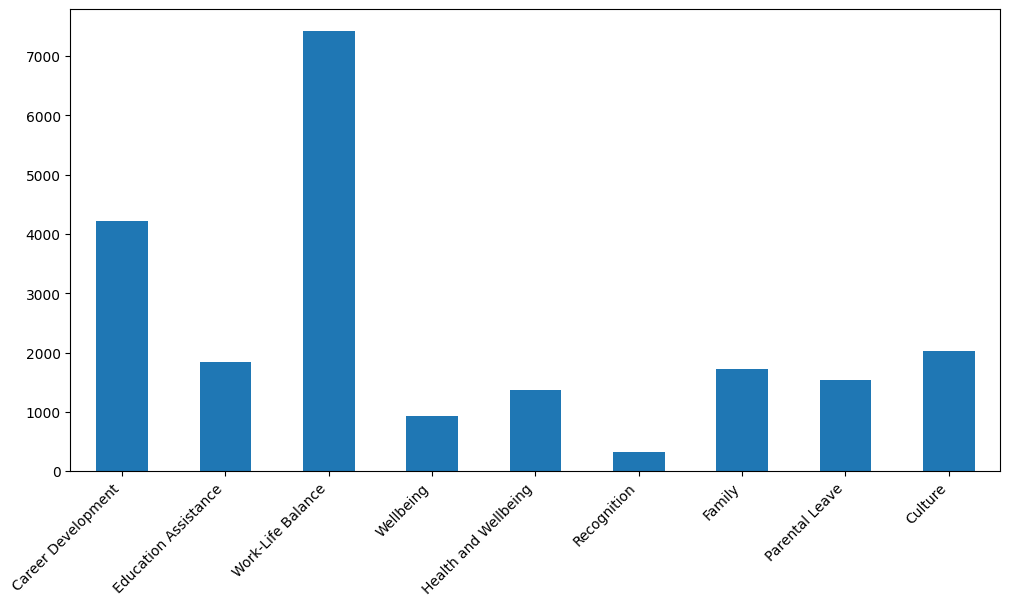

In [161]:

    
# plot a clustered bar chart for all benefits
benefit_counts = even_sample[benefits3].sum()
benefit_counts.plot(kind='bar', figsize=(12, 6))
# rotate x labels
# set labels as benefits3_labels
plt.xticks(ticks=range(len(benefits3_labels)),labels=benefits3_labels)
plt.xticks(rotation=45, ha='right')



In [126]:
even_sample['PARENTAL_LEAVE'].value_counts()

PARENTAL_LEAVE
False    18463
True      1537
Name: count, dtype: int64

# Plot Coefficients

In [133]:
coefficients = []
errors = []
pvalues = []
for model in benefit_models:
    try:
        coef = model.params['AI ROLE']
        err = model.bse['AI ROLE']
        pvalue = model.pvalues['AI ROLE'].round(3)
    except:
        coef = None
        err = None
        pvalue = None

    coefficients.append(coef)
    errors.append(err)
    pvalues.append(pvalue)

# Creating DataFrame
results = {
    'Label': benefits,
    'Coefficient': coefficients,
    'Error': errors,
    'P-Value': pvalues
}

results_df = pd.DataFrame(results)



NameError: name 'benefit_models' is not defined

In [99]:
results_df

,Label,Coefficient,Error,P-Value
0,CAREER_DEV,0.014385,0.046544,0.757
1,EDU_ASSISTANCE,0.017867,0.065632,0.785
2,WLB,-0.174237,0.040048,0.000
3,WELLBEING,0.533514,0.094908,0.000
4,HEALTH_WELLBEING,0.396024,0.077583,0.000
5,RECOGNITION,0.094436,0.154843,0.542
6,FAMILY,0.447628,0.070732,0.000
7,PARENTAL_LEAVE,NaN,NaN,NaN
8,CULTURE,0.662077,0.068184,0.000


In [100]:
results_df['Model Iteration'] = 'Baseline'

In [101]:
results_df

,Label,Coefficient,Error,P-Value,Model Iteration
0,CAREER_DEV,0.014385,0.046544,0.757,Baseline
1,EDU_ASSISTANCE,0.017867,0.065632,0.785,Baseline
2,WLB,-0.174237,0.040048,0.000,Baseline
3,WELLBEING,0.533514,0.094908,0.000,Baseline
4,HEALTH_WELLBEING,0.396024,0.077583,0.000,Baseline
5,RECOGNITION,0.094436,0.154843,0.542,Baseline
6,FAMILY,0.447628,0.070732,0.000,Baseline
7,PARENTAL_LEAVE,NaN,NaN,NaN,Baseline
8,CULTURE,0.662077,0.068184,0.000,Baseline


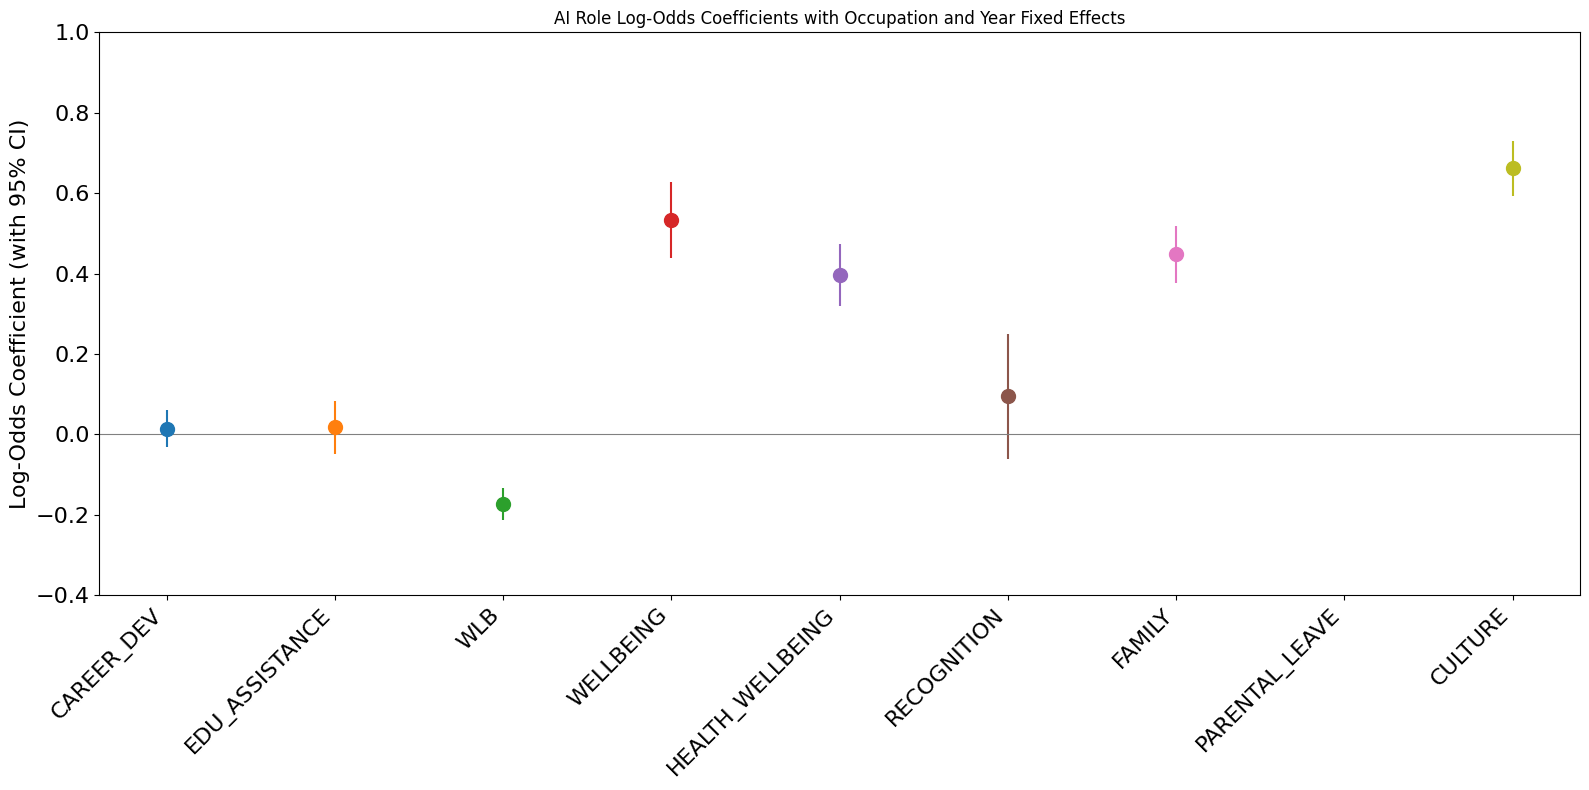

In [102]:
fig, ax = plt.subplots(figsize=(16, 8))
# Define colors for the 9 AI skills categories
# colors = ['#E69F00', '#56B4E9', '#009E73', '#CC79A7', '#F0E442', '#0072B2', '#D55E00', '#CC79A7', '#999999']
cmap = plt.get_cmap("tab10")
colors = [cmap(i) for i in range(len(results_df))]
# Plot each AI skill category
for i, row in results_df.iterrows():
    ax.errorbar(
        i, row['Coefficient'], 
        yerr=row['Error'], 
        fmt='o', color=colors[i], label=row['Label'], markersize = 10
    )

# Customize plot
ax.set_xticks(range(len(results_df)))
ax.set_xticklabels(results_df['Label'], rotation=45, ha='right', fontsize = 16)
# ax.set_title('Coefficients for 9 AI Skills Categories')
# ax.set_xlabel('AI Skills Categories', fontsize = 18)
ax.set_ylabel('Log-Odds Coefficient (with 95% CI)', fontsize = 16)
ax.axhline(0, color='grey', linewidth=0.8)
# ax.axhline(average_coefficient, color='grey', linestyle='--', linewidth=1, label='Average Coefficient')

# Increase the size of y-ticks
ax.tick_params(axis='y', labelsize=16)
ax.set_title('AI Role Log-Odds Coefficients with Occupation and Year Fixed Effects')
ax.set_ylim(-0.4, 1.0)
# Add legend
# ax.legend(title='AI Skills', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize = 16, title_fontsize = 16)

plt.tight_layout() 
plt.show()

In [103]:
coefficients = []
errors = []
pvalues = []
for model in benefit_models_2:
    try:
        coef = model.params['AI ROLE']
        err = model.bse['AI ROLE']
        pvalue = model.pvalues['AI ROLE'].round(3)
    except:
        coef = None
        err = None
        pvalue = None

    coefficients.append(coef)
    errors.append(err)
    pvalues.append(pvalue)

# Creating DataFrame
results_2 = {
    'Label': benefits,
    'Coefficient': coefficients,
    'Error': errors,
    'P-Value': pvalues
}

results_df_2 = pd.DataFrame(results_2)



In [104]:
results_df_2

,Label,Coefficient,Error,P-Value
0,CAREER_DEV,-0.036362,0.048276,0.451
1,EDU_ASSISTANCE,-0.008501,0.068242,0.901
2,WLB,-0.175347,0.041446,0.000
3,WELLBEING,NaN,NaN,NaN
4,HEALTH_WELLBEING,0.289475,0.080226,0.000
5,RECOGNITION,NaN,NaN,NaN
6,FAMILY,0.466633,0.073098,0.000
7,PARENTAL_LEAVE,NaN,NaN,NaN
8,CULTURE,0.593803,0.070137,0.000


In [105]:
results_df_2['Model Iteration'] = 'Individual Controls'

In [106]:
coefficients = []
errors = []
pvalues = []
for model in benefit_models_3:
    try:
        coef = model.params['AI ROLE']
        err = model.bse['AI ROLE']
        pvalue = model.pvalues['AI ROLE'].round(3)
    except:
        coef = None
        err = None
        pvalue = None

    coefficients.append(coef)
    errors.append(err)
    pvalues.append(pvalue)

# Creating DataFrame
results_3 = {
    'Label': benefits,
    'Coefficient': coefficients,
    'Error': errors,
    'P-Value': pvalues
}

results_df_3 = pd.DataFrame(results_3)



In [107]:
results_df_3['Model Iteration'] = 'With Salary'

In [108]:
df = pd.concat([results_df, results_df_2, results_df_3])

In [109]:
df

,Label,Coefficient,Error,P-Value,Model Iteration
0,CAREER_DEV,0.014385,0.046544,0.757,Baseline
1,EDU_ASSISTANCE,0.017867,0.065632,0.785,Baseline
2,WLB,-0.174237,0.040048,0.000,Baseline
3,WELLBEING,0.533514,0.094908,0.000,Baseline
4,HEALTH_WELLBEING,0.396024,0.077583,0.000,Baseline
5,RECOGNITION,0.094436,0.154843,0.542,Baseline
6,FAMILY,0.447628,0.070732,0.000,Baseline
7,PARENTAL_LEAVE,NaN,NaN,NaN,Baseline
8,CULTURE,0.662077,0.068184,0.000,Baseline
0,CAREER_DEV,-0.036362,0.048276,0.451,Individual Controls


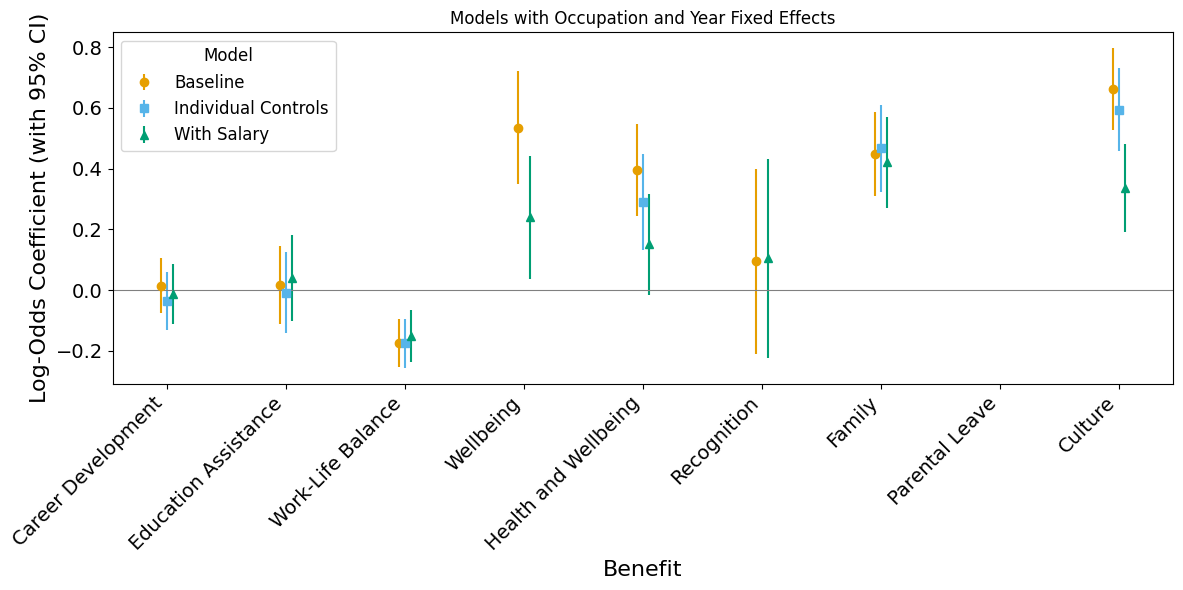

In [206]:
import matplotlib.pyplot as plt
import numpy as np

# Define colors for each model
colors = ['#E69F00', '#56B4E9', '#009E73', '#CC79A7']
# Calculate the 95% confidence intervals
df['Lower_CI'] = df['Coefficient'] - 1.96 * df['Error']
df['Upper_CI'] = df['Coefficient'] + 1.96 * df['Error']

# Plotting
fig, ax = plt.subplots(figsize=(12, 6))

# benefits = benefits
model_iterations = df['Model Iteration'].unique()
markers = ['o', 's', '^']  # Different markers for model iterations
positions = []
current_pos = 0

# Store legend handles and labels to avoid duplicates
handles, labels = [], []

for benefit in benefits:
    benefit_data = df[df['Label'] == benefit]
    benefit_positions = []
    for i, model in enumerate(model_iterations):
        model_data = benefit_data[benefit_data['Model Iteration'] == model]
        if not model_data.empty:
            pos = current_pos + i * 0.2  # Adjust spacing between model_iterations within the same benefit
            handle = ax.errorbar(
                pos, model_data['Coefficient'].values, 
                yerr=[model_data['Coefficient'].values - model_data['Lower_CI'].values, 
                      model_data['Upper_CI'].values - model_data['Coefficient'].values], 
                fmt=markers[i], color=colors[i], label=model if benefit == benefits[0] else ""
            )
            benefit_positions.append(pos)
            if benefit == benefits[0]:  # Add handles and labels only for the first benefit to avoid duplicates
                handles.append(handle)
                labels.append(model)
    positions.extend(benefit_positions)
    current_pos += len(model_iterations) + 1  # Add more space between different benefits

# Customize plot
benefit_ticks = [(positions[i * len(model_iterations)] + positions[(i + 1) * len(model_iterations) - 1]) / 2 for i in range(len(benefits))]
ax.set_xticks(benefit_ticks)
ax.tick_params(axis='y', labelsize=14)
ax.set_xticklabels(benefits3_labels, rotation=45, fontsize = 14, ha='right')
# ax.set_title('AI Skill Coefficients by benefit and Occupation')
ax.set_xlabel('Benefit', fontsize=16)
ax.set_ylabel('Log-Odds Coefficient (with 95% CI)', fontsize=16)
ax.axhline(0, color='grey', linewidth=0.8)
ax.legend(handles, labels, title='Model', bbox_to_anchor=(0, 1), loc = 'upper left', fontsize = 12, title_fontsize = 12)
# ax.axhline(average_coefficient, color='black', linestyle='--', linewidth=1, label='Average Coefficient')
plt.title('Models with Occupation and Year Fixed Effects')
plt.tight_layout()
plt.savefig('../figures/model_coefficients_plot_3.png')
plt.show()


# Models with Industry

In [ ]:
industry_counts = even_sample['NAICS_2022_2_NAME'].value_counts()
small_industries = industry_counts[industry_counts < 30].index  # Set a threshold (e.g., 10 observations)
even_sample['NAICS_2022_2_NAME'] = even_sample['NAICS_2022_2_NAME'].replace(small_industries, 'Other')

In [214]:
benefits4

['EDU_ASSISTANCE',
 'WLB',
 'PAID_LEAVE',
 'HEALTH_WELLBEING',
 'PARENTAL_LEAVE',
 'CULTURE',
 'wfh_wham']

In [7]:
even_sample_wham = pd.read_parquet('../data/small_samples/salary_wham_sample_20k.parquet.gzip')

In [48]:
even_sample_wham.groupby('YEAR').size()

YEAR
2018       2
2019    1661
2020    2155
2021    3672
2022    5411
2023    7099
dtype: int64

In [49]:
even_sample.groupby('YEAR').size()

YEAR
2018    1365
2019    1576
2020    1984
2021    3401
2022    5020
2023    6654
dtype: int64

In [145]:
benefit_models_industry = []
for benefit in benefits4:
    print(benefit)
    print('--'*100)
    if (benefit == 'wfh_wham' or benefit == 'PARENTAL_LEAVE'):
        model = run_logit_model(even_sample_wham, dependent = benefit, predictor='AI ROLE', cat_controls = [year, industry], get_vif=True)
    else:
        model = run_logit_model(even_sample, dependent = benefit, predictor='AI ROLE', cat_controls = [year, industry], get_vif = True)
    benefit_models_industry.append(model)

EDU_ASSISTANCE
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
Number of NAs in dependent: 0
Correlation Matrix
                                                    const   AI ROLE      2019  \
const                                                 NaN       NaN       NaN   
AI ROLE                                               NaN  1.000000 -0.084253   
2019                                                  NaN -0.084253  1.000000   
2020                                                  NaN -0.117419 -0.097057   
2021                                                  NaN -0.050708 -0.132388   
2022                                                  NaN  0.053046 -0.169310   
2023                                                  NaN  0.147714 -0.206515   
Administrative and Support and Waste Management...    NaN -0.011337  0.071987   
Arts, 

Calculating VIF: 100%|██████████| 25/25 [00:00<00:00, 47.81it/s]


                                             features        VIF
0                                               const  49.904567
1                                             AI ROLE   1.200541
2                                                2019   1.988543
3                                                2020   2.221599
4                                                2021   2.935123
5                                                2022   3.580719
6                                                2023   4.091281
7   Administrative and Support and Waste Managemen...   5.922210
8                 Arts, Entertainment, and Recreation   1.187173
9                                        Construction   1.501066
10                               Educational Services   2.454385
11                              Finance and Insurance   3.349507
12                  Health Care and Social Assistance   2.809243
13                                        Information   2.564328
14                       

Calculating VIF: 100%|██████████| 25/25 [00:00<00:00, 45.87it/s]


                                             features        VIF
0                                               const  49.904567
1                                             AI ROLE   1.200541
2                                                2019   1.988543
3                                                2020   2.221599
4                                                2021   2.935123
5                                                2022   3.580719
6                                                2023   4.091281
7   Administrative and Support and Waste Managemen...   5.922210
8                 Arts, Entertainment, and Recreation   1.187173
9                                        Construction   1.501066
10                               Educational Services   2.454385
11                              Finance and Insurance   3.349507
12                  Health Care and Social Assistance   2.809243
13                                        Information   2.564328
14                       

...

                                             features        VIF
0                                               const  45.521943
1                                             AI ROLE   1.211129
2                                                2020   2.057764
3                                                2021   2.649970
4                                                2022   3.174201
5                                                2023   3.570372
6   Administrative and Support and Waste Managemen...   5.562375
7                 Arts, Entertainment, and Recreation   1.181834
8                                        Construction   1.550239
9                                Educational Services   2.403091
10                              Finance and Insurance   3.420258
11                  Health Care and Social Assistance   2.768611
12                                        Information   2.606078
13                                      Manufacturing   3.165354
14                       

Calculating VIF: 100%|██████████| 25/25 [00:00<00:00, 27.39it/s]


                                             features        VIF
0                                               const  49.904567
1                                             AI ROLE   1.200541
2                                                2019   1.988543
3                                                2020   2.221599
4                                                2021   2.935123
5                                                2022   3.580719
6                                                2023   4.091281
7   Administrative and Support and Waste Managemen...   5.922210
8                 Arts, Entertainment, and Recreation   1.187173
9                                        Construction   1.501066
10                               Educational Services   2.454385
11                              Finance and Insurance   3.349507
12                  Health Care and Social Assistance   2.809243
13                                        Information   2.564328
14                       

Calculating VIF: 100%|██████████| 24/24 [00:00<00:00, 30.89it/s]


                                             features        VIF
0                                               const  45.521943
1                                             AI ROLE   1.211129
2                                                2020   2.057764
3                                                2021   2.649970
4                                                2022   3.174201
5                                                2023   3.570372
6   Administrative and Support and Waste Managemen...   5.562375
7                 Arts, Entertainment, and Recreation   1.181834
8                                        Construction   1.550239
9                                Educational Services   2.403091
10                              Finance and Insurance   3.420258
11                  Health Care and Social Assistance   2.768611
12                                        Information   2.606078
13                                      Manufacturing   3.165354
14                       

In [53]:
benefit_models_industry[0].converged

True

## Diagnostics

In [ ]:
even_sample[industry].value_counts()

NAICS_2022_2_NAME
Unclassified Industry                                                       3885
Administrative and Support and Waste Management and Remediation Services    3383
Professional, Scientific, and Technical Services                            2840
Finance and Insurance                                                       1401
Manufacturing                                                               1308
Health Care and Social Assistance                                           1115
Retail Trade                                                                 986
Information                                                                  902
Educational Services                                                         867
Public Administration                                                        589
Accommodation and Food Services                                              565
Wholesale Trade                                                              447
Transporta

In [54]:
even_sample[even_sample['PARENTAL_LEAVE']==1].groupby([year]).size()

YEAR
2018      4
2019     12
2020     42
2021    163
2022    300
2023    915
dtype: int64

In [102]:
even_sample_wham[even_sample_wham['PARENTAL_LEAVE']==1].groupby([year]).size()

YEAR
2019     14
2020     37
2021    165
2022    341
2023    932
dtype: int64

In [103]:
even_sample.groupby('YEAR').size()

YEAR
2018    1365
2019    1576
2020    1984
2021    3401
2022    5020
2023    6654
dtype: int64

In [106]:
even_sample.groupby([industry, 'HEALTH_WELLBEING']).size()

NAICS_2022_2_NAME                                                         HEALTH_WELLBEING
Accommodation and Food Services                                           False                536
                                                                          True                  29
Administrative and Support and Waste Management and Remediation Services  False               3277
                                                                          True                 106
Agriculture, Forestry, Fishing and Hunting                                False                 25
Arts, Entertainment, and Recreation                                       False                101
                                                                          True                   8
Construction                                                              False                286
                                                                          True                   9
Educational Servic

In [137]:
even_sample.groupby(['YEAR', industry, 'PARENTAL_LEAVE']).size().reset_index()

,YEAR,NAICS_2022_2_NAME,PARENTAL_LEAVE,0
0,2018,Accommodation and Food Services,False,29
1,2018,Administrative and Support and Waste Managemen...,False,424
2,2018,Administrative and Support and Waste Managemen...,True,1
3,2018,"Arts, Entertainment, and Recreation",False,11
4,2018,Construction,False,22
...,...,...,...,...
195,2023,Unclassified Industry,True,72
196,2023,Utilities,False,24
197,2023,Utilities,True,2
198,2023,Wholesale Trade,False,135


In [140]:
pd.set_option('display.max_rows', 120)

In [141]:
even_sample.groupby(['YEAR', industry]).size().sort_values().reset_index()

,YEAR,NAICS_2022_2_NAME,0
0,2019,Management of Companies and Enterprises,2
1,2018,Management of Companies and Enterprises,2
2,2019,Other,4
3,2020,Utilities,4
4,2018,Utilities,4
5,2020,Management of Companies and Enterprises,4
6,2018,Other,5
7,2020,Other,5
8,2019,Utilities,6
9,2021,Other,8


In [144]:
run_logit_model(even_sample, dependent = 'PARENTAL_LEAVE', predictor='AI ROLE', cat_controls = [industry, 'YEAR'], get_vif = True)


Number of NAs in dependent: 0
Correlation Matrix
                                                    const   AI ROLE  \
const                                                 NaN       NaN   
AI ROLE                                               NaN  1.000000   
Administrative and Support and Waste Management...    NaN -0.022912   
Arts, Entertainment, and Recreation                   NaN -0.036847   
Construction                                          NaN -0.085595   
Educational Services                                  NaN  0.012487   
Finance and Insurance                                 NaN  0.159720   
Health Care and Social Assistance                     NaN -0.148474   
Information                                           NaN  0.139780   
Manufacturing                                         NaN  0.099092   
Other                                                 NaN -0.008313   
Other Services (except Public Administration)         NaN -0.067541   
Professional, Scientific, an

Calculating VIF: 100%|██████████| 24/24 [00:00<00:00, 52.63it/s]


                                             features        VIF
0                                               const  46.647499
1                                             AI ROLE   1.208284
2   Administrative and Support and Waste Managemen...   5.580291
3                 Arts, Entertainment, and Recreation   1.177247
4                                        Construction   1.488554
5                                Educational Services   2.427560
6                               Finance and Insurance   3.413076
7                   Health Care and Social Assistance   2.780848
8                                         Information   2.605847
9                                       Manufacturing   3.218093
10                                              Other   1.154994
11      Other Services (except Public Administration)   1.548938
12   Professional, Scientific, and Technical Services   5.320682
13                              Public Administration   1.913525
14                 Real E

In [183]:
# benefit_models = []
# for benefit in benefits:
#     print(benefit)
#     print('--'*100)
#     model = run_logit_model(even_sample, dependent = benefit, predictor='AI ROLE', cat_controls = [year, occupation])
#     benefit_models.append(model)

In [184]:
# # export benefit_models to pickle
# import pickle
# if path[-3:] == 'csv:':
#     with open('../exports/benefit_models.pkl', 'wb') as f:
#         pickle.dump(benefit_models, f)
# elif path == '../data/salary_sample_body_benefits.parquet.gzip'
#     with open('../exports/benefit_models_fromlarge.pkl', 'wb') as f:
#         pickle.dump(benefit_models, f)

# With Individual Controls

In [157]:
benefit_models_industry_2 = []
for benefit in benefits4:
    print(benefit)
    print('--'*100)
    if (benefit == 'wfh_wham'or benefit == 'PARENTAL_LEAVE'):
        model = run_logit_model(even_sample_wham, dependent = benefit, predictor='AI ROLE', cat_controls = [year, industry, education, experience],  ref_category = {education: "No Education Listed", experience: 'None Listed'}, get_vif = False)
    else:
        model = run_logit_model(even_sample, dependent = benefit, predictor='AI ROLE', cat_controls = [year, industry, education, experience],  ref_category = {education: "No Education Listed", experience: 'None Listed'}, get_vif = False)
    benefit_models_industry_2.append(model)

EDU_ASSISTANCE
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
Number of NAs in dependent: 0
Optimization terminated successfully.
         Current function value: 0.274160
         Iterations 8
                           Logit Regression Results                           
Dep. Variable:         EDU_ASSISTANCE   No. Observations:                20000
Model:                          Logit   Df Residuals:                    19965
Method:                           MLE   Df Model:                           34
Date:                Fri, 18 Oct 2024   Pseudo R-squ.:                 0.06639
Time:                        14:29:21   Log-Likelihood:                -5483.2
converged:                       True   LL-Null:                       -5873.1
Covariance Type:            nonrobust   LLR p-value:                6.463e-142
                    

In [186]:
benefit_models_industry_2

# With Salary Control

In [158]:
benefit_models_industry_3 = []
for benefit in benefits4:
    print(benefit)
    print('--'*100)
    if (benefit == 'wfh_wham' or benefit == 'PARENTAL_LEAVE'):
        model = run_logit_model(even_sample_wham, dependent = benefit, predictor='AI ROLE', cat_controls = [year, industry, education, experience], cont_controls = ['LOG_SALARY'], ref_category = {education: "No Education Listed", experience: 'None Listed'})
    else:
        model = run_logit_model(even_sample, dependent = benefit, predictor='AI ROLE', cat_controls = [year, industry, education, experience], cont_controls = ['LOG_SALARY'], ref_category = {education: "No Education Listed", experience: 'None Listed'})
    benefit_models_industry_3.append(model)

EDU_ASSISTANCE
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
Number of NAs in dependent: 0
Optimization terminated successfully.
         Current function value: 0.274160
         Iterations 8
                           Logit Regression Results                           
Dep. Variable:         EDU_ASSISTANCE   No. Observations:                20000
Model:                          Logit   Df Residuals:                    19964
Method:                           MLE   Df Model:                           35
Date:                Fri, 18 Oct 2024   Pseudo R-squ.:                 0.06639
Time:                        14:29:26   Log-Likelihood:                -5483.2
converged:                       True   LL-Null:                       -5873.1
Covariance Type:            nonrobust   LLR p-value:                3.123e-141
                    

# Plot Coefficients

In [146]:
coefficients = []
errors = []
pvalues = []
converged_list = []
observations = []
for model in benefit_models_industry:
    try:
        coef = model.params['AI ROLE']
        err = model.bse['AI ROLE']
        pvalue = model.pvalues['AI ROLE'].round(3)
        converged = model.converged 
        obs = model.nobs       
    except:
        coef = None
        err = None
        pvalue = None
        converged = None
        obs = None
        

    coefficients.append(coef)
    errors.append(err)
    pvalues.append(pvalue)
    converged_list.append(converged)
    observations.append(obs)

# Creating DataFrame
results_industry = {
    'Label': benefits4,
    'Coefficient': coefficients,
    'Error': errors,
    'P-Value': pvalues,
    'Converged': converged_list, 
    'Observations': observations
}

results_industry_df = pd.DataFrame(results_industry)



In [147]:
results_industry_df['Model Iteration'] = 'Baseline'

In [148]:
results_industry_df

,Label,Coefficient,Error,P-Value,Converged,Observations,Model Iteration
0,EDU_ASSISTANCE,-0.063706,0.057876,0.271,True,20000,Baseline
1,WLB,-0.225228,0.033614,0.000,True,20000,Baseline
2,PAID_LEAVE,-0.276833,0.033960,0.000,True,20000,Baseline
3,HEALTH_WELLBEING,0.265943,0.068936,0.000,True,20000,Baseline
4,PARENTAL_LEAVE,0.733075,0.068033,0.000,True,19998,Baseline
5,CULTURE,0.829563,0.051869,0.000,True,20000,Baseline
6,wfh_wham,1.585156,0.042863,0.000,True,19998,Baseline


In [159]:
coefficients = []
errors = []
pvalues = []
converged_list = []
observations = []
for model in benefit_models_industry_2:
    try:
        coef = model.params['AI ROLE']
        err = model.bse['AI ROLE']
        pvalue = model.pvalues['AI ROLE'].round(3)
        converged = model.converged 
        obs = model.nobs       
    except:
        coef = None
        err = None
        pvalue = None
        converged = None
        obs = None
        

    coefficients.append(coef)
    errors.append(err)
    pvalues.append(pvalue)
    converged_list.append(converged)
    observations.append(obs)

# Creating DataFrame
results_industry_2 = {
    'Label': benefits4,
    'Coefficient': coefficients,
    'Error': errors,
    'P-Value': pvalues,
    'Converged': converged_list, 
    'Observations': observations
}

results_industry_df_2 = pd.DataFrame(results_industry_2)



In [160]:
results_industry_df_2['Model Iteration'] = 'Individual Controls'

In [161]:
coefficients = []
errors = []
pvalues = []
converged_list = []
observations = []
for model in benefit_models_industry_3:
    try:
        coef = model.params['AI ROLE']
        err = model.bse['AI ROLE']
        pvalue = model.pvalues['AI ROLE'].round(3)
        converged = model.converged 
        obs = model.nobs       
    except:
        coef = None
        err = None
        pvalue = None
        converged = None
        obs = None
        

    coefficients.append(coef)
    errors.append(err)
    pvalues.append(pvalue)
    converged_list.append(converged)
    observations.append(obs)

# Creating DataFrame
results_industry_3 = {
    'Label': benefits4,
    'Coefficient': coefficients,
    'Error': errors,
    'P-Value': pvalues,
    'Converged': converged_list, 
    'Observations': observations
}

results_industry_df_3 = pd.DataFrame(results_industry_3)



In [162]:
results_industry_df_3['Model Iteration'] = 'With Salary'

In [163]:
industry_df = pd.concat([results_industry_df, results_industry_df_2, results_industry_df_3])

In [164]:
industry_df

,Label,Coefficient,Error,P-Value,Converged,Observations,Model Iteration
0,EDU_ASSISTANCE,-0.063706,0.057876,0.271,True,20000,Baseline
1,WLB,-0.225228,0.033614,0.000,True,20000,Baseline
2,PAID_LEAVE,-0.276833,0.033960,0.000,True,20000,Baseline
3,HEALTH_WELLBEING,0.265943,0.068936,0.000,True,20000,Baseline
4,PARENTAL_LEAVE,0.733075,0.068033,0.000,True,19998,Baseline
5,CULTURE,0.829563,0.051869,0.000,True,20000,Baseline
6,wfh_wham,1.585156,0.042863,0.000,True,19998,Baseline
0,EDU_ASSISTANCE,0.000599,0.066341,0.993,True,20000,Individual Controls
1,WLB,-0.184123,0.038658,0.000,True,20000,Individual Controls
2,PAID_LEAVE,-0.219550,0.039071,0.000,True,20000,Individual Controls


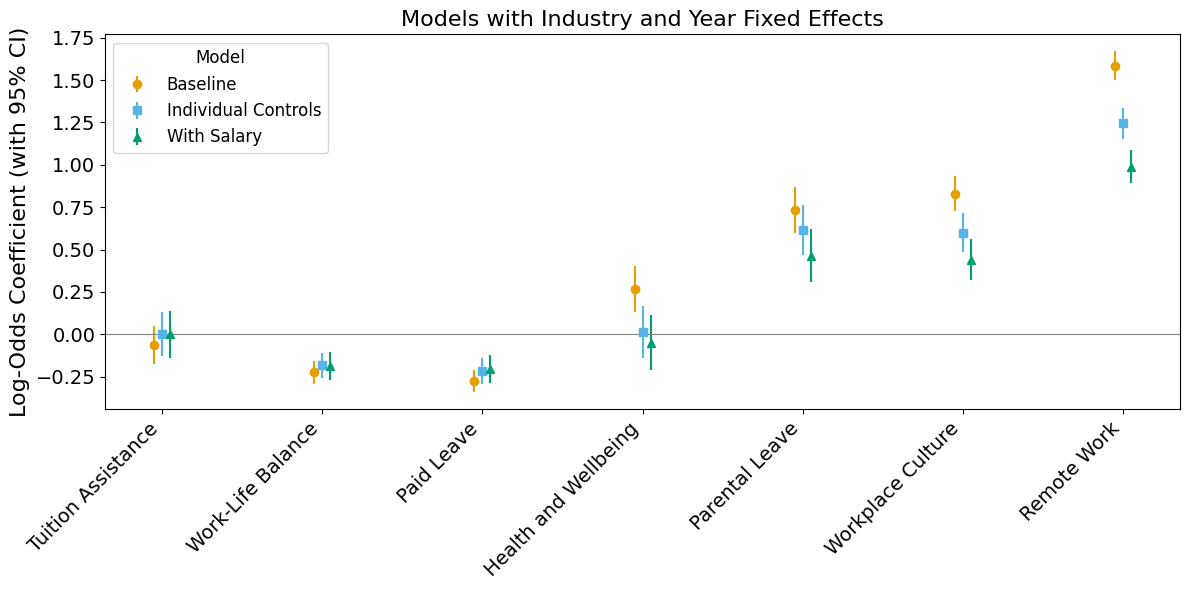

In [167]:
import matplotlib.pyplot as plt
import numpy as np

# Define colors for each model
colors = ['#E69F00', '#56B4E9', '#009E73', '#CC79A7']
# Calculate the 95% confidence intervals
industry_df['Lower_CI'] = industry_df['Coefficient'] - 1.96 * industry_df['Error']
industry_df['Upper_CI'] = industry_df['Coefficient'] + 1.96 * industry_df['Error']

# Plotting
fig, ax = plt.subplots(figsize=(12, 6))

# benefits = benefits
model_iterations = industry_df['Model Iteration'].unique()
markers = ['o', 's', '^']  # Different markers for model iterations
positions = []
current_pos = 0

# Store legend handles and labels to avoid duplicates
handles, labels = [], []

for benefit in benefits4:
    benefit_data = industry_df[industry_df['Label'] == benefit]
    benefit_positions = []
    for i, model in enumerate(model_iterations):
        model_data = benefit_data[benefit_data['Model Iteration'] == model]
        if not model_data.empty:
            pos = current_pos + i * 0.2  # Adjust spacing between model_iterations within the same benefit
            handle = ax.errorbar(
                pos, model_data['Coefficient'].values, 
                yerr=[model_data['Coefficient'].values - model_data['Lower_CI'].values, 
                      model_data['Upper_CI'].values - model_data['Coefficient'].values], 
                fmt=markers[i], color=colors[i], label=model if benefit == benefits4[0] else ""
            )
            benefit_positions.append(pos)
            if benefit == benefits4[0]:  # Add handles and labels only for the first benefit to avoid duplicates
                handles.append(handle)
                labels.append(model)
            if not model_data['Converged'].values[0]:  # Assuming Converged is boolean
                ax.plot(pos, model_data['Coefficient'].values[0], 'rx', markersize=12, label='Did Not Converge')
        
    positions.extend(benefit_positions)
    current_pos += len(model_iterations) + 1  # Add more space between different benefits

# Customize plot
benefit_ticks = [(positions[i * len(model_iterations)] + positions[(i + 1) * len(model_iterations) - 1]) / 2 for i in range(len(benefits4))]
ax.set_xticks(benefit_ticks, labels = benefits4_labels)
ax.tick_params(axis='y', labelsize=14)
ax.set_xticklabels(benefits4_labels, rotation=45, fontsize = 14, ha='right')
# ax.set_title('AI Skill Coefficients by benefit and Occupation')
ax.set_xlabel(None)
ax.set_ylabel('Log-Odds Coefficient (with 95% CI)', fontsize=16)
ax.axhline(0, color='grey', linewidth=0.8)
ax.legend(handles, labels, title='Model', bbox_to_anchor=(0, 1), loc = 'upper left', fontsize = 12, title_fontsize = 12)
# ax.axhline(average_coefficient, color='black', linestyle='--', linewidth=1, label='Average Coefficient')
plt.title('Models with Industry and Year Fixed Effects', fontsize = 16)
plt.tight_layout()
plt.savefig('../figures/model_coefficients_plot_industry_converged.png')
plt.show()


# Without Salary

In [168]:
even_sample_nosal = pd.read_parquet('../../data/nosalary_sample_20k.parquet.gzip')

In [181]:
even_sample_nosal = even_sample_nosal[even_sample_nosal['YEAR'] != 2018]

In [182]:
even_sample_nosal.groupby('YEAR').size()

YEAR
2019    3360
2020    3361
2021    4399
2022    5082
2023    3796
dtype: int64

In [183]:
benefit_models_industry = []
for benefit in benefits4:
    print(benefit)
    print('--'*100)
    if (benefit == 'wfh_wham' or benefit == 'PARENTAL_LEAVE'):
        model = run_logit_model(even_sample_nosal, dependent = benefit, predictor='AI ROLE', cat_controls = [year, industry], get_vif=True)
    else:
        model = run_logit_model(even_sample_nosal, dependent = benefit, predictor='AI ROLE', cat_controls = [year, industry], get_vif = True)
    benefit_models_industry.append(model)

EDU_ASSISTANCE
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
Number of NAs in dependent: 0
Correlation Matrix
                                                    const   AI ROLE      2020  \
const                                                 NaN       NaN       NaN   
AI ROLE                                               NaN  1.000000  0.000714   
2020                                                  NaN  0.000714  1.000000   
2021                                                  NaN  0.001381 -0.238685   
2022                                                  NaN  0.036353 -0.262354   
2023                                                  NaN -0.035910 -0.217558   
Administrative and Support and Waste Management...    NaN -0.052871  0.029757   
Arts, Entertainment, and Recreation                   NaN -0.040507 -0.011869   
Constr

Calculating VIF: 100%|██████████| 25/25 [00:00<00:00, 45.77it/s]


                                             features        VIF
0                                               const  36.082012
1                                             AI ROLE   1.187648
2                                                2020   1.667771
3                                                2021   1.804215
4                                                2022   1.878658
5                                                2023   1.730952
6   Administrative and Support and Waste Managemen...   3.894602
7                 Arts, Entertainment, and Recreation   1.142985
8                                        Construction   1.427879
9                                Educational Services   2.127172
10                              Finance and Insurance   3.278429
11                  Health Care and Social Assistance   3.164345
12                                        Information   2.541579
13            Management of Companies and Enterprises   1.102572
14                       

Calculating VIF: 100%|██████████| 25/25 [00:00<00:00, 49.09it/s]


                                             features        VIF
0                                               const  36.082012
1                                             AI ROLE   1.187648
2                                                2020   1.667771
3                                                2021   1.804215
4                                                2022   1.878658
5                                                2023   1.730952
6   Administrative and Support and Waste Managemen...   3.894602
7                 Arts, Entertainment, and Recreation   1.142985
8                                        Construction   1.427879
9                                Educational Services   2.127172
10                              Finance and Insurance   3.278429
11                  Health Care and Social Assistance   3.164345
12                                        Information   2.541579
13            Management of Companies and Enterprises   1.102572
14                       

...

                                             features        VIF
0                                               const  36.082012
1                                             AI ROLE   1.187648
2                                                2020   1.667771
3                                                2021   1.804215
4                                                2022   1.878658
5                                                2023   1.730952
6   Administrative and Support and Waste Managemen...   3.894602
7                 Arts, Entertainment, and Recreation   1.142985
8                                        Construction   1.427879
9                                Educational Services   2.127172
10                              Finance and Insurance   3.278429
11                  Health Care and Social Assistance   3.164345
12                                        Information   2.541579
13            Management of Companies and Enterprises   1.102572
14                       

Calculating VIF: 100%|██████████| 25/25 [00:00<00:00, 43.61it/s]


                                             features        VIF
0                                               const  36.082012
1                                             AI ROLE   1.187648
2                                                2020   1.667771
3                                                2021   1.804215
4                                                2022   1.878658
5                                                2023   1.730952
6   Administrative and Support and Waste Managemen...   3.894602
7                 Arts, Entertainment, and Recreation   1.142985
8                                        Construction   1.427879
9                                Educational Services   2.127172
10                              Finance and Insurance   3.278429
11                  Health Care and Social Assistance   3.164345
12                                        Information   2.541579
13            Management of Companies and Enterprises   1.102572
14                       

Calculating VIF: 100%|██████████| 25/25 [00:00<00:00, 42.75it/s]


                                             features        VIF
0                                               const  36.082012
1                                             AI ROLE   1.187648
2                                                2020   1.667771
3                                                2021   1.804215
4                                                2022   1.878658
5                                                2023   1.730952
6   Administrative and Support and Waste Managemen...   3.894602
7                 Arts, Entertainment, and Recreation   1.142985
8                                        Construction   1.427879
9                                Educational Services   2.127172
10                              Finance and Insurance   3.278429
11                  Health Care and Social Assistance   3.164345
12                                        Information   2.541579
13            Management of Companies and Enterprises   1.102572
14                       

## With Individual Controls

In [184]:
benefit_models_industry_2 = []
for benefit in benefits4:
    print(benefit)
    print('--'*100)
    if (benefit == 'wfh_wham'or benefit == 'PARENTAL_LEAVE'):
        model = run_logit_model(even_sample_nosal, dependent = benefit, predictor='AI ROLE', cat_controls = [year, industry, education, experience],  ref_category = {education: "No Education Listed", experience: 'None Listed'}, get_vif = False)
    else:
        model = run_logit_model(even_sample_nosal, dependent = benefit, predictor='AI ROLE', cat_controls = [year, industry, education, experience],  ref_category = {education: "No Education Listed", experience: 'None Listed'}, get_vif = False)
    benefit_models_industry_2.append(model)

EDU_ASSISTANCE
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
Number of NAs in dependent: 0
Optimization terminated successfully.
         Current function value: 0.237896
         Iterations 8
                           Logit Regression Results                           
Dep. Variable:         EDU_ASSISTANCE   No. Observations:                19998
Model:                          Logit   Df Residuals:                    19963
Method:                           MLE   Df Model:                           34
Date:                Fri, 18 Oct 2024   Pseudo R-squ.:                 0.05635
Time:                        14:43:52   Log-Likelihood:                -4757.5
converged:                       True   LL-Null:                       -5041.5
Covariance Type:            nonrobust   LLR p-value:                 3.827e-98
                    

In [ ]:
benefit_models_industry_2

## Plot Coefficients

In [185]:
coefficients = []
errors = []
pvalues = []
converged_list = []
observations = []
for model in benefit_models_industry:
    try:
        coef = model.params['AI ROLE']
        err = model.bse['AI ROLE']
        pvalue = model.pvalues['AI ROLE'].round(3)
        converged = model.converged 
        obs = model.nobs       
    except:
        coef = None
        err = None
        pvalue = None
        converged = None
        obs = None
        

    coefficients.append(coef)
    errors.append(err)
    pvalues.append(pvalue)
    converged_list.append(converged)
    observations.append(obs)

# Creating DataFrame
results_industry = {
    'Label': benefits4,
    'Coefficient': coefficients,
    'Error': errors,
    'P-Value': pvalues,
    'Converged': converged_list, 
    'Observations': observations
}

results_industry_df = pd.DataFrame(results_industry)



In [186]:
results_industry_df['Model Iteration'] = 'Baseline'

In [187]:
results_industry_df

,Label,Coefficient,Error,P-Value,Converged,Observations,Model Iteration
0,EDU_ASSISTANCE,-0.242744,0.062898,0.000,True,19998,Baseline
1,WLB,-0.357075,0.038474,0.000,True,19998,Baseline
2,PAID_LEAVE,-0.424061,0.039599,0.000,True,19998,Baseline
3,HEALTH_WELLBEING,0.140241,0.077120,0.069,True,19998,Baseline
4,PARENTAL_LEAVE,0.643782,0.080057,0.000,True,19998,Baseline
5,CULTURE,0.737417,0.046912,0.000,True,19998,Baseline
6,wfh_wham,1.144903,0.048542,0.000,True,19998,Baseline


In [188]:
coefficients = []
errors = []
pvalues = []
converged_list = []
observations = []
for model in benefit_models_industry_2:
    try:
        coef = model.params['AI ROLE']
        err = model.bse['AI ROLE']
        pvalue = model.pvalues['AI ROLE'].round(3)
        converged = model.converged 
        obs = model.nobs       
    except:
        coef = None
        err = None
        pvalue = None
        converged = None
        obs = None
        

    coefficients.append(coef)
    errors.append(err)
    pvalues.append(pvalue)
    converged_list.append(converged)
    observations.append(obs)

# Creating DataFrame
results_industry_2 = {
    'Label': benefits4,
    'Coefficient': coefficients,
    'Error': errors,
    'P-Value': pvalues,
    'Converged': converged_list, 
    'Observations': observations
}

results_industry_df_2 = pd.DataFrame(results_industry_2)



In [189]:
results_industry_df_2['Model Iteration'] = 'Individual Controls'

In [190]:
industry_df = pd.concat([results_industry_df, results_industry_df_2])

In [191]:
industry_df

,Label,Coefficient,Error,P-Value,Converged,Observations,Model Iteration
0,EDU_ASSISTANCE,-0.242744,0.062898,0.000,True,19998,Baseline
1,WLB,-0.357075,0.038474,0.000,True,19998,Baseline
2,PAID_LEAVE,-0.424061,0.039599,0.000,True,19998,Baseline
3,HEALTH_WELLBEING,0.140241,0.077120,0.069,True,19998,Baseline
4,PARENTAL_LEAVE,0.643782,0.080057,0.000,True,19998,Baseline
5,CULTURE,0.737417,0.046912,0.000,True,19998,Baseline
6,wfh_wham,1.144903,0.048542,0.000,True,19998,Baseline
0,EDU_ASSISTANCE,-0.223949,0.070366,0.001,True,19998,Individual Controls
1,WLB,-0.309260,0.043171,0.000,True,19998,Individual Controls
2,PAID_LEAVE,-0.348551,0.044380,0.000,True,19998,Individual Controls


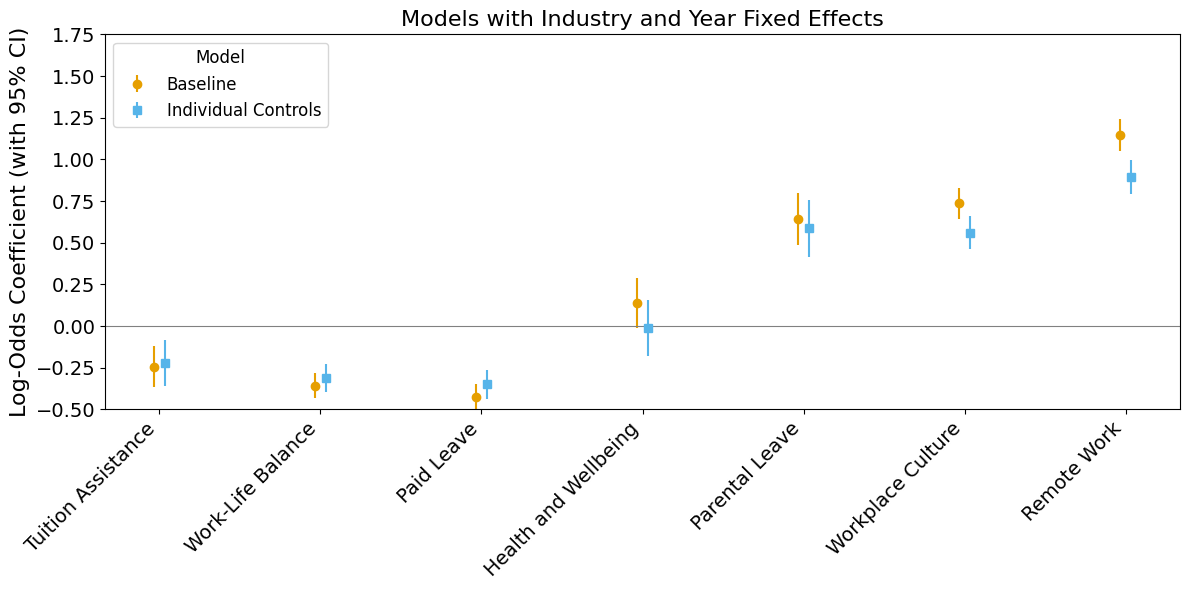

In [194]:
import matplotlib.pyplot as plt
import numpy as np

# Define colors for each model
colors = ['#E69F00', '#56B4E9', '#009E73', '#CC79A7']
# Calculate the 95% confidence intervals
industry_df['Lower_CI'] = industry_df['Coefficient'] - 1.96 * industry_df['Error']
industry_df['Upper_CI'] = industry_df['Coefficient'] + 1.96 * industry_df['Error']

# Plotting
fig, ax = plt.subplots(figsize=(12, 6))

# benefits = benefits
model_iterations = industry_df['Model Iteration'].unique()
markers = ['o', 's', '^']  # Different markers for model iterations
positions = []
current_pos = 0

# Store legend handles and labels to avoid duplicates
handles, labels = [], []

for benefit in benefits4:
    benefit_data = industry_df[industry_df['Label'] == benefit]
    benefit_positions = []
    for i, model in enumerate(model_iterations):
        model_data = benefit_data[benefit_data['Model Iteration'] == model]
        if not model_data.empty:
            pos = current_pos + i * 0.2  # Adjust spacing between model_iterations within the same benefit
            handle = ax.errorbar(
                pos, model_data['Coefficient'].values, 
                yerr=[model_data['Coefficient'].values - model_data['Lower_CI'].values, 
                      model_data['Upper_CI'].values - model_data['Coefficient'].values], 
                fmt=markers[i], color=colors[i], label=model if benefit == benefits4[0] else ""
            )
            benefit_positions.append(pos)
            if benefit == benefits4[0]:  # Add handles and labels only for the first benefit to avoid duplicates
                handles.append(handle)
                labels.append(model)
            if not model_data['Converged'].values[0]:  # Assuming Converged is boolean
                ax.plot(pos, model_data['Coefficient'].values[0], 'rx', markersize=12, label='Did Not Converge')
        
    positions.extend(benefit_positions)
    current_pos += len(model_iterations) + 1  # Add more space between different benefits

# Customize plot
benefit_ticks = [(positions[i * len(model_iterations)] + positions[(i + 1) * len(model_iterations) - 1]) / 2 for i in range(len(benefits4))]
ax.set_xticks(benefit_ticks, labels = benefits4_labels)
ax.tick_params(axis='y', labelsize=14)
ax.set_xticklabels(benefits4_labels, rotation=45, fontsize = 14, ha='right')
# ax.set_title('AI Skill Coefficients by benefit and Occupation')
ax.set_xlabel(None)
ax.set_ylabel('Log-Odds Coefficient (with 95% CI)', fontsize=16)
ax.set_ylim(-0.5, 1.75)
ax.axhline(0, color='grey', linewidth=0.8)
ax.legend(handles, labels, title='Model', bbox_to_anchor=(0, 1), loc = 'upper left', fontsize = 12, title_fontsize = 12)
# ax.axhline(average_coefficient, color='black', linestyle='--', linewidth=1, label='Average Coefficient')
plt.title('Models with Industry and Year Fixed Effects', fontsize = 16)
plt.tight_layout()
# plt.savefig('../figures/model_coefficients_plot_industry_converged.png')
plt.show()


In [196]:
even_sample.columns

Index(['ID', 'CITY_NAME', 'COUNTY_NAME', 'STATE_NAME', 'NAICS_2022_2',
       'NAICS_2022_2_NAME', 'MIN_EDULEVELS_NAME', 'EMPLOYMENT_TYPE',
       'EMPLOYMENT_TYPE_NAME', 'IS_INTERNSHIP', 'REMOTE_TYPE',
       'REMOTE_TYPE_NAME', 'SKILLS', 'SKILLS_NAME', 'POSTED',
       'LAST_UPDATED_DATE', 'ONET', 'ONET_NAME', 'ONET_2019', 'ONET_2019_NAME',
       'SOC_2021_2_NAME', 'SOC_2021_2', 'MIN_YEARS_EXPERIENCE', 'COMPANY',
       'COMPANY_NAME', 'COMPANY_RAW', 'AI ROLE', 'wfh_wham_prob', 'wfh_wham',
       'YEAR', 'BODY', 'EDU_ASSISTANCE', 'WLB', 'PAID_LEAVE',
       'HEALTH_WELLBEING', 'PARENTAL_LEAVE', 'CULTURE', 'EXPERIENCE_BUCKET',
       'SALARY', 'LOG_SALARY'],
      dtype='object')

# Remote Keywords

In [19]:
industry_counts = even_sample['NAICS_2022_2_NAME'].value_counts()
small_industries = industry_counts[industry_counts < 30].index  # Set a threshold (e.g., 10 observations)
even_sample['NAICS_2022_2_NAME'] = even_sample['NAICS_2022_2_NAME'].replace(small_industries, 'Other')

In [20]:
benefits4

['EDU_ASSISTANCE',
 'PAID_LEAVE',
 'HEALTH_WELLBEING',
 'PARENTAL_LEAVE',
 'CULTURE',
 'wfh_wham']

In [47]:
benefits5 = ['EDU_ASSISTANCE',
 'PAID_LEAVE',
 'HEALTH_WELLBEING',
 'PARENTAL_LEAVE',
 'CULTURE',
 'wfh_wham',
 'Remote_KW']

In [22]:
even_sample.head()

,ID,CITY_NAME,COUNTY_NAME,STATE_NAME,NAICS_2022_2,NAICS_2022_2_NAME,MIN_EDULEVELS_NAME,EMPLOYMENT_TYPE,EMPLOYMENT_TYPE_NAME,IS_INTERNSHIP,...,EDU_ASSISTANCE,WLB,PAID_LEAVE,HEALTH_WELLBEING,PARENTAL_LEAVE,CULTURE,EXPERIENCE_BUCKET,SALARY,LOG_SALARY,Remote_KW
0,c24b748985411eb72c35c6bd0858ca3317043224,"Arlington, VA","Arlington, VA",Virginia,92,Public Administration,Bachelor's degree,3,Part-time / full-time,False,...,True,False,False,True,False,False,1-2 years,66425.0,11.103829,1
1,648ef7de9588114c53107fb5c990cd0b176e4a8f,"Irving, TX","Dallas, TX",Texas,51,Information,Bachelor's degree,1,Full-time (> 32 hours),False,...,False,False,False,False,False,False,6-10 years,186000.0,12.133502,0
2,41116976922260bb94ac44092bb578e246eb3bb6,"Charlotte, NC","Mecklenburg, NC",North Carolina,56,Administrative and Support and Waste Managemen...,High school or GED,1,Full-time (> 32 hours),False,...,False,False,False,False,False,False,11-20 years,133120.0,11.799006,0
3,d8d796257493113fb722989284ce9d34d2eeb49a,"Irvine, CA","Orange, CA",California,51,Information,Bachelor's degree,1,Full-time (> 32 hours),False,...,False,True,True,False,False,False,3-5 years,95000.0,11.461632,1
4,35f59149dae5bd4c84a6048396f0012364d80ecb,"Seattle, WA","King, WA",Washington,99,Unclassified Industry,No Education Listed,1,Full-time (> 32 hours),False,...,False,False,False,False,False,False,11-20 years,177500.0,12.086726,0


In [48]:
benefit_models_industry = []
for benefit in benefits5:
    print(benefit)
    print('--'*100)
    model = run_logit_model(even_sample, dependent = benefit, predictor='AI ROLE', cat_controls = [year, industry], get_vif = True)
    benefit_models_industry.append(model)

EDU_ASSISTANCE
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
Number of NAs in dependent: 0
Correlation Matrix
                                                    const   AI ROLE      2019  \
const                                                 NaN       NaN       NaN   
AI ROLE                                               NaN  1.000000 -0.084253   
2019                                                  NaN -0.084253  1.000000   
2020                                                  NaN -0.117419 -0.097057   
2021                                                  NaN -0.050708 -0.132388   
2022                                                  NaN  0.053046 -0.169310   
2023                                                  NaN  0.147714 -0.206515   
Administrative and Support and Waste Management...    NaN -0.011337  0.071987   
Arts, 

Calculating VIF:   0%|          | 0/25 [00:00<?, ?it/s]

Calculating VIF: 100%|██████████| 25/25 [00:00<00:00, 35.55it/s]


                                             features        VIF
0                                               const  49.904567
1                                             AI ROLE   1.200541
2                                                2019   1.988543
3                                                2020   2.221599
4                                                2021   2.935123
5                                                2022   3.580719
6                                                2023   4.091281
7   Administrative and Support and Waste Managemen...   5.922210
8                 Arts, Entertainment, and Recreation   1.187173
9                                        Construction   1.501066
10                               Educational Services   2.454385
11                              Finance and Insurance   3.349507
12                  Health Care and Social Assistance   2.809243
13                                        Information   2.564328
14                       

Calculating VIF: 100%|██████████| 25/25 [00:00<00:00, 34.62it/s]


...

                                             features        VIF
0                                               const  49.904567
1                                             AI ROLE   1.200541
2                                                2019   1.988543
3                                                2020   2.221599
4                                                2021   2.935123
5                                                2022   3.580719
6                                                2023   4.091281
7   Administrative and Support and Waste Managemen...   5.922210
8                 Arts, Entertainment, and Recreation   1.187173
9                                        Construction   1.501066
10                               Educational Services   2.454385
11                              Finance and Insurance   3.349507
12                  Health Care and Social Assistance   2.809243
13                                        Information   2.564328
14                       

Calculating VIF: 100%|██████████| 24/24 [00:00<00:00, 43.33it/s]


                                             features        VIF
0                                               const  46.565769
1                                             AI ROLE   1.207001
2                                                2020   2.028157
3                                                2021   2.646176
4                                                2022   3.166452
5                                                2023   3.563143
6   Administrative and Support and Waste Managemen...   5.538002
7                 Arts, Entertainment, and Recreation   1.177869
8                                        Construction   1.488491
9                                Educational Services   2.412001
10                              Finance and Insurance   3.410559
11                  Health Care and Social Assistance   2.777835
12                                        Information   2.604061
13                                      Manufacturing   3.206134
14                       

Calculating VIF: 100%|██████████| 25/25 [00:00<00:00, 40.68it/s]


                                             features        VIF
0                                               const  49.904567
1                                             AI ROLE   1.200541
2                                                2019   1.988543
3                                                2020   2.221599
4                                                2021   2.935123
5                                                2022   3.580719
6                                                2023   4.091281
7   Administrative and Support and Waste Managemen...   5.922210
8                 Arts, Entertainment, and Recreation   1.187173
9                                        Construction   1.501066
10                               Educational Services   2.454385
11                              Finance and Insurance   3.349507
12                  Health Care and Social Assistance   2.809243
13                                        Information   2.564328
14                       

In [49]:
benefit_models_industry_2 = []
for benefit in benefits5:
    print(benefit)
    print('--'*100)
    model = run_logit_model(even_sample, dependent = benefit, predictor='AI ROLE', cat_controls = [year, industry, education, experience],  ref_category = {education: "No Education Listed", experience: 'None Listed'}, get_vif = False)
    benefit_models_industry_2.append(model)

EDU_ASSISTANCE
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
Number of NAs in dependent: 0
Optimization terminated successfully.
         Current function value: 0.274160
         Iterations 8
                           Logit Regression Results                           
Dep. Variable:         EDU_ASSISTANCE   No. Observations:                20000
Model:                          Logit   Df Residuals:                    19965
Method:                           MLE   Df Model:                           34
Date:                Tue, 29 Oct 2024   Pseudo R-squ.:                 0.06639
Time:                        22:22:35   Log-Likelihood:                -5483.2
converged:                       True   LL-Null:                       -5873.1
Covariance Type:            nonrobust   LLR p-value:                6.463e-142
                    

In [50]:
benefit_models_industry_3 = []
for benefit in benefits5:
    print(benefit)
    print('--'*100)
    model = run_logit_model(even_sample, dependent = benefit, predictor='AI ROLE', cat_controls = [year, industry, education, experience], cont_controls = ['LOG_SALARY'], ref_category = {education: "No Education Listed", experience: 'None Listed'})
    benefit_models_industry_3.append(model)

EDU_ASSISTANCE
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
Number of NAs in dependent: 0
Optimization terminated successfully.
         Current function value: 0.274160
         Iterations 8
                           Logit Regression Results                           
Dep. Variable:         EDU_ASSISTANCE   No. Observations:                20000
Model:                          Logit   Df Residuals:                    19964
Method:                           MLE   Df Model:                           35
Date:                Tue, 29 Oct 2024   Pseudo R-squ.:                 0.06639
Time:                        22:22:44   Log-Likelihood:                -5483.2
converged:                       True   LL-Null:                       -5873.1
Covariance Type:            nonrobust   LLR p-value:                3.123e-141
                    

Optimization terminated successfully.
         Current function value: 0.610831
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:             PAID_LEAVE   No. Observations:                20000
Model:                          Logit   Df Residuals:                    19964
Method:                           MLE   Df Model:                           35
Date:                Tue, 29 Oct 2024   Pseudo R-squ.:                 0.04931
Time:                        22:22:44   Log-Likelihood:                -12217.
converged:                       True   LL-Null:                       -12850.
Covariance Type:            nonrobust   LLR p-value:                1.237e-243
                                                                               coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------------------------------

In [51]:
coefficients = []
errors = []
pvalues = []
converged_list = []
observations = []
for model in benefit_models_industry:
    try:
        coef = model.params['AI ROLE']
        err = model.bse['AI ROLE']
        pvalue = model.pvalues['AI ROLE'].round(3)
        converged = model.converged 
        obs = model.nobs       
    except:
        coef = None
        err = None
        pvalue = None
        converged = None
        obs = None
        

    coefficients.append(coef)
    errors.append(err)
    pvalues.append(pvalue)
    converged_list.append(converged)
    observations.append(obs)

# Creating DataFrame
results_industry = {
    'Label': benefits5,
    'Coefficient': coefficients,
    'Error': errors,
    'P-Value': pvalues,
    'Converged': converged_list, 
    'Observations': observations
}

results_industry_df = pd.DataFrame(results_industry)



In [52]:
results_industry_df['Model Iteration'] = 'Baseline'

In [53]:
results_industry_df

,Label,Coefficient,Error,P-Value,Converged,Observations,Model Iteration
0,EDU_ASSISTANCE,-0.063706,0.057876,0.271,True,20000,Baseline
1,PAID_LEAVE,-0.276833,0.033960,0.000,True,20000,Baseline
2,HEALTH_WELLBEING,0.265943,0.068936,0.000,True,20000,Baseline
3,PARENTAL_LEAVE,0.713372,0.069906,0.000,True,18635,Baseline
4,CULTURE,0.829563,0.051869,0.000,True,20000,Baseline
5,wfh_wham,1.634762,0.044687,0.000,True,18442,Baseline
6,Remote_KW,1.046213,0.039312,0.000,True,20000,Baseline


In [54]:
coefficients = []
errors = []
pvalues = []
converged_list = []
observations = []
for model in benefit_models_industry_2:
    try:
        coef = model.params['AI ROLE']
        err = model.bse['AI ROLE']
        pvalue = model.pvalues['AI ROLE'].round(3)
        converged = model.converged 
        obs = model.nobs       
    except:
        coef = None
        err = None
        pvalue = None
        converged = None
        obs = None
        

    coefficients.append(coef)
    errors.append(err)
    pvalues.append(pvalue)
    converged_list.append(converged)
    observations.append(obs)

# Creating DataFrame
results_industry_2 = {
    'Label': benefits5,
    'Coefficient': coefficients,
    'Error': errors,
    'P-Value': pvalues,
    'Converged': converged_list, 
    'Observations': observations
}

results_industry_df_2 = pd.DataFrame(results_industry_2)



In [55]:
results_industry_df_2['Model Iteration'] = 'Individual Controls'

In [56]:
coefficients = []
errors = []
pvalues = []
converged_list = []
observations = []
for model in benefit_models_industry_3:
    try:
        coef = model.params['AI ROLE']
        err = model.bse['AI ROLE']
        pvalue = model.pvalues['AI ROLE'].round(3)
        converged = model.converged 
        obs = model.nobs       
    except:
        coef = None
        err = None
        pvalue = None
        converged = None
        obs = None
        

    coefficients.append(coef)
    errors.append(err)
    pvalues.append(pvalue)
    converged_list.append(converged)
    observations.append(obs)

# Creating DataFrame
results_industry_3 = {
    'Label': benefits5,
    'Coefficient': coefficients,
    'Error': errors,
    'P-Value': pvalues,
    'Converged': converged_list, 
    'Observations': observations
}

results_industry_df_3 = pd.DataFrame(results_industry_3)



In [57]:
results_industry_df_3['Model Iteration'] = 'With Salary'

In [58]:
industry_df = pd.concat([results_industry_df, results_industry_df_2, results_industry_df_3])

In [46]:
industry_df

,Label,Coefficient,Error,P-Value,Converged,Observations,Model Iteration
0,EDU_ASSISTANCE,-0.063706,0.057876,0.271,True,20000,Baseline
1,PAID_LEAVE,-0.276833,0.033960,0.000,True,20000,Baseline
2,HEALTH_WELLBEING,0.265943,0.068936,0.000,True,20000,Baseline
3,PARENTAL_LEAVE,0.713372,0.069906,0.000,True,18635,Baseline
4,CULTURE,0.829563,0.051869,0.000,True,20000,Baseline
5,wfh_wham,1.634762,0.044687,0.000,True,18442,Baseline
6,Remote_KW,1.046213,0.039312,0.000,True,20000,Baseline
0,EDU_ASSISTANCE,0.000599,0.066341,0.993,True,20000,Individual Controls
1,PAID_LEAVE,-0.219550,0.039071,0.000,True,20000,Individual Controls
2,HEALTH_WELLBEING,0.011879,0.078878,0.880,True,20000,Individual Controls


In [63]:
benefits4_labels

['Tuition Assistance',
 'Paid Leave',
 'Health and Wellbeing',
 'Parental Leave',
 'Workplace Culture',
 'Remote Work']

In [64]:

benefits5_labels = ['Tuition Assistance',
 'Paid Leave',
 'Health and Wellbeing',
 'Parental Leave',
 'Workplace Culture',
 'Remote Work', 'Remote Work Keywords']

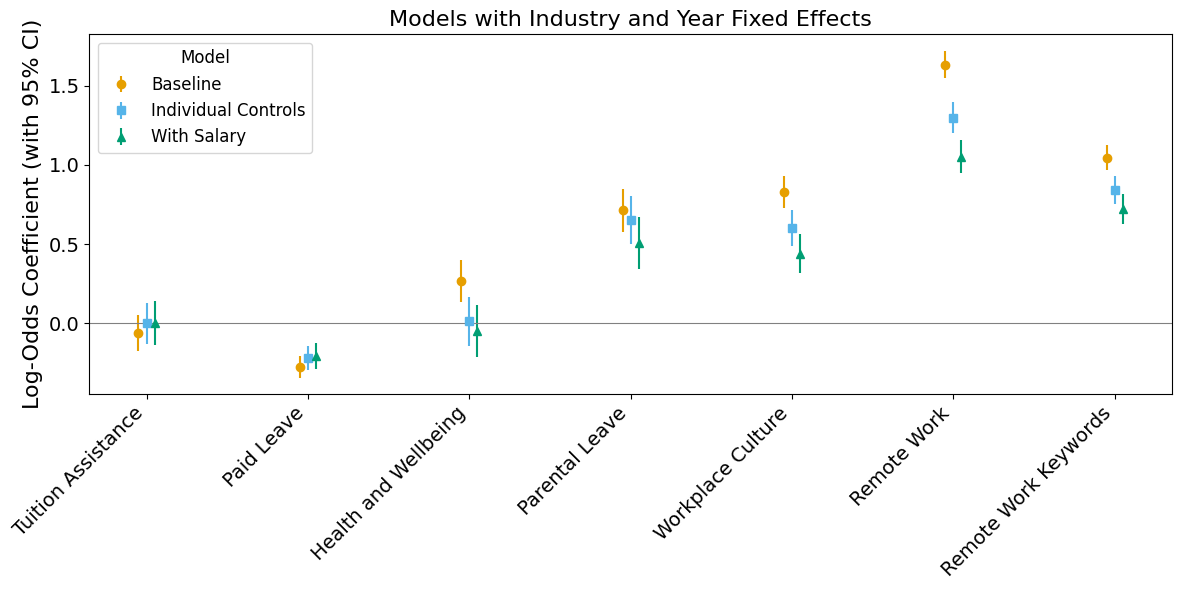

In [65]:
import matplotlib.pyplot as plt
import numpy as np

# Define colors for each model
colors = ['#E69F00', '#56B4E9', '#009E73', '#CC79A7']
# Calculate the 95% confidence intervals
industry_df['Lower_CI'] = industry_df['Coefficient'] - 1.96 * industry_df['Error']
industry_df['Upper_CI'] = industry_df['Coefficient'] + 1.96 * industry_df['Error']

# Plotting
fig, ax = plt.subplots(figsize=(12, 6))

# benefits = benefits
model_iterations = industry_df['Model Iteration'].unique()
markers = ['o', 's', '^']  # Different markers for model iterations
positions = []
current_pos = 0

# Store legend handles and labels to avoid duplicates
handles, labels = [], []

for benefit in benefits5:
    benefit_data = industry_df[industry_df['Label'] == benefit]
    benefit_positions = []
    for i, model in enumerate(model_iterations):
        model_data = benefit_data[benefit_data['Model Iteration'] == model]
        if not model_data.empty:
            pos = current_pos + i * 0.2  # Adjust spacing between model_iterations within the same benefit
            handle = ax.errorbar(
                pos, model_data['Coefficient'].values, 
                yerr=[model_data['Coefficient'].values - model_data['Lower_CI'].values, 
                      model_data['Upper_CI'].values - model_data['Coefficient'].values], 
                fmt=markers[i], color=colors[i], label=model if benefit == benefits5[0] else ""
            )
            benefit_positions.append(pos)
            if benefit == benefits5[0]:  # Add handles and labels only for the first benefit to avoid duplicates
                handles.append(handle)
                labels.append(model)
            if not model_data['Converged'].values[0]:  # Assuming Converged is boolean
                ax.plot(pos, model_data['Coefficient'].values[0], 'rx', markersize=12, label='Did Not Converge')
        
    positions.extend(benefit_positions)
    current_pos += len(model_iterations) + 1  # Add more space between different benefits

# Customize plot
benefit_ticks = [(positions[i * len(model_iterations)] + positions[(i + 1) * len(model_iterations) - 1]) / 2 for i in range(len(benefits5))]
ax.set_xticks(benefit_ticks, labels = benefits5_labels)
ax.tick_params(axis='y', labelsize=14)
ax.set_xticklabels(benefits5_labels, rotation=45, fontsize = 14, ha='right')
# ax.set_title('AI Skill Coefficients by benefit and Occupation')
ax.set_xlabel(None)
ax.set_ylabel('Log-Odds Coefficient (with 95% CI)', fontsize=16)
ax.axhline(0, color='grey', linewidth=0.8)
ax.legend(handles, labels, title='Model', bbox_to_anchor=(0, 1), loc = 'upper left', fontsize = 12, title_fontsize = 12)
# ax.axhline(average_coefficient, color='black', linestyle='--', linewidth=1, label='Average Coefficient')
plt.title('Models with Industry and Year Fixed Effects', fontsize = 16)
plt.tight_layout()
plt.savefig('../figures/model_coefficients_plot_industry_converged.png')
plt.show()


# 2024

# Experience

In [31]:
# Define buckets for years of experience
bins = [-2, -1, 0, 2, 5, 10, 20, 100]
labels = ['Missing', '0 years', '1-2 years', '3-5 years', '6-10 years', '11-20 years', '21+ years']


In [32]:
even_sample['EXPERIENCE_BUCKET'] = pd.cut(even_sample['MIN_YEARS_EXPERIENCE'], bins=bins, labels=labels, right=True)

In [33]:
even_sample['EXPERIENCE_BUCKET']=even_sample['EXPERIENCE_BUCKET'].astype(str)

In [34]:
# replace nan with 'None Listed'
even_sample['EXPERIENCE_BUCKET'] = even_sample['EXPERIENCE_BUCKET'].replace('nan', 'None Listed')

In [35]:
even_sample['EXPERIENCE_BUCKET'].value_counts(dropna=False)

EXPERIENCE_BUCKET
None Listed    8546
3-5 years      4534
1-2 years      3317
6-10 years     2683
0 years         528
11-20 years     392
Name: count, dtype: int64

# Log Salary

In [36]:
even_sample['LOG_SALARY'] = np.log(even_sample['SALARY'])

In [37]:
even_sample.to_parquet('../data/small_samples/2024_salary_sample.parquet.gzip', compression='gzip')

In [38]:
industry_counts = even_sample['NAICS_2022_2_NAME'].value_counts()
small_industries = industry_counts[industry_counts < 30].index  # Set a threshold (e.g., 10 observations)
even_sample['NAICS_2022_2_NAME'] = even_sample['NAICS_2022_2_NAME'].replace(small_industries, 'Other')

In [19]:
benefits4

['EDU_ASSISTANCE',
 'PAID_LEAVE',
 'HEALTH_WELLBEING',
 'PARENTAL_LEAVE',
 'CULTURE',
 'REMOTE_KW']

In [43]:
benefit_models_industry = []
for benefit in benefits4:
    print(benefit)
    print('--'*100)
    model = run_logit_model(even_sample, dependent = benefit, predictor='AI ROLE', cat_controls = [year, industry], get_vif = False)
    benefit_models_industry.append(model)

EDU_ASSISTANCE
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
Number of NAs in dependent: 0
Optimization terminated successfully.
         Current function value: 0.295244
         Iterations 8
                           Logit Regression Results                           
Dep. Variable:         EDU_ASSISTANCE   No. Observations:                20000
Model:                          Logit   Df Residuals:                    19974
Method:                           MLE   Df Model:                           25
Date:                Wed, 06 Nov 2024   Pseudo R-squ.:                 0.05994
Time:                        04:14:11   Log-Likelihood:                -5904.9
converged:                       True   LL-Null:                       -6281.4
Covariance Type:            nonrobust   LLR p-value:                9.860e-143
                    

In [40]:
benefit_models_industry_2 = []
for benefit in benefits4:
    print(benefit)
    print('--'*100)
    model = run_logit_model(even_sample, dependent = benefit, predictor='AI ROLE', cat_controls = [year, industry, education, experience],  ref_category = {education: "No Education Listed", experience: 'None Listed'}, get_vif = False)
    benefit_models_industry_2.append(model)

EDU_ASSISTANCE
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
Number of NAs in dependent: 0
Optimization terminated successfully.
         Current function value: 0.291734
         Iterations 8
                           Logit Regression Results                           
Dep. Variable:         EDU_ASSISTANCE   No. Observations:                20000
Model:                          Logit   Df Residuals:                    19964
Method:                           MLE   Df Model:                           35
Date:                Wed, 06 Nov 2024   Pseudo R-squ.:                 0.07111
Time:                        04:12:55   Log-Likelihood:                -5834.7
converged:                       True   LL-Null:                       -6281.4
Covariance Type:            nonrobust   LLR p-value:                6.464e-165
                    

In [41]:
benefit_models_industry_3 = []
for benefit in benefits4:
    print(benefit)
    print('--'*100)
    model = run_logit_model(even_sample, dependent = benefit, predictor='AI ROLE', cat_controls = [year, industry, education, experience], cont_controls = ['LOG_SALARY'], ref_category = {education: "No Education Listed", experience: 'None Listed'})
    benefit_models_industry_3.append(model)

EDU_ASSISTANCE
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
Number of NAs in dependent: 0
Optimization terminated successfully.
         Current function value: 0.291729
         Iterations 8
                           Logit Regression Results                           
Dep. Variable:         EDU_ASSISTANCE   No. Observations:                20000
Model:                          Logit   Df Residuals:                    19963
Method:                           MLE   Df Model:                           36
Date:                Wed, 06 Nov 2024   Pseudo R-squ.:                 0.07113
Time:                        04:13:01   Log-Likelihood:                -5834.6
converged:                       True   LL-Null:                       -6281.4
Covariance Type:            nonrobust   LLR p-value:                2.986e-164
                    

In [44]:
coefficients = []
errors = []
pvalues = []
converged_list = []
observations = []
for model in benefit_models_industry:
    try:
        coef = model.params['AI ROLE']
        err = model.bse['AI ROLE']
        pvalue = model.pvalues['AI ROLE'].round(3)
        converged = model.converged 
        obs = model.nobs       
    except:
        coef = None
        err = None
        pvalue = None
        converged = None
        obs = None
        

    coefficients.append(coef)
    errors.append(err)
    pvalues.append(pvalue)
    converged_list.append(converged)
    observations.append(obs)

# Creating DataFrame
results_industry = {
    'Label': benefits4,
    'Coefficient': coefficients,
    'Error': errors,
    'P-Value': pvalues,
    'Converged': converged_list, 
    'Observations': observations
}

results_industry_df = pd.DataFrame(results_industry)



In [46]:
results_industry_df['Model Iteration'] = 'Baseline'

In [47]:
results_industry_df

,Label,Coefficient,Error,P-Value,Converged,Observations,Model Iteration
0,EDU_ASSISTANCE,0.069242,0.056153,0.218,True,20000,Baseline
1,PAID_LEAVE,-0.190585,0.033735,0.000,True,20000,Baseline
2,HEALTH_WELLBEING,0.255262,0.066471,0.000,True,20000,Baseline
3,PARENTAL_LEAVE,0.744895,0.064437,0.000,True,18936,Baseline
4,CULTURE,0.798177,0.049817,0.000,True,20000,Baseline
5,REMOTE_KW,1.329771,0.046715,0.000,True,20000,Baseline


In [45]:
coefficients = []
errors = []
pvalues = []
converged_list = []
observations = []
for model in benefit_models_industry_2:
    try:
        coef = model.params['AI ROLE']
        err = model.bse['AI ROLE']
        pvalue = model.pvalues['AI ROLE'].round(3)
        converged = model.converged 
        obs = model.nobs       
    except:
        coef = None
        err = None
        pvalue = None
        converged = None
        obs = None
        

    coefficients.append(coef)
    errors.append(err)
    pvalues.append(pvalue)
    converged_list.append(converged)
    observations.append(obs)

# Creating DataFrame
results_industry_2 = {
    'Label': benefits4,
    'Coefficient': coefficients,
    'Error': errors,
    'P-Value': pvalues,
    'Converged': converged_list, 
    'Observations': observations
}

results_industry_df_2 = pd.DataFrame(results_industry_2)



In [48]:
results_industry_df_2['Model Iteration'] = 'Individual Controls'

In [49]:
coefficients = []
errors = []
pvalues = []
converged_list = []
observations = []
for model in benefit_models_industry_3:
    try:
        coef = model.params['AI ROLE']
        err = model.bse['AI ROLE']
        pvalue = model.pvalues['AI ROLE'].round(3)
        converged = model.converged 
        obs = model.nobs       
    except:
        coef = None
        err = None
        pvalue = None
        converged = None
        obs = None
        

    coefficients.append(coef)
    errors.append(err)
    pvalues.append(pvalue)
    converged_list.append(converged)
    observations.append(obs)

# Creating DataFrame
results_industry_3 = {
    'Label': benefits4,
    'Coefficient': coefficients,
    'Error': errors,
    'P-Value': pvalues,
    'Converged': converged_list, 
    'Observations': observations
}

results_industry_df_3 = pd.DataFrame(results_industry_3)



In [50]:
results_industry_df_3['Model Iteration'] = 'With Salary'

In [51]:
industry_df = pd.concat([results_industry_df, results_industry_df_2, results_industry_df_3])

In [52]:
industry_df

,Label,Coefficient,Error,P-Value,Converged,Observations,Model Iteration
0,EDU_ASSISTANCE,0.069242,0.056153,0.218,True,20000,Baseline
1,PAID_LEAVE,-0.190585,0.033735,0.000,True,20000,Baseline
2,HEALTH_WELLBEING,0.255262,0.066471,0.000,True,20000,Baseline
3,PARENTAL_LEAVE,0.744895,0.064437,0.000,True,18936,Baseline
4,CULTURE,0.798177,0.049817,0.000,True,20000,Baseline
5,REMOTE_KW,1.329771,0.046715,0.000,True,20000,Baseline
0,EDU_ASSISTANCE,0.110516,0.063347,0.081,True,20000,Individual Controls
1,PAID_LEAVE,-0.169521,0.038168,0.000,True,20000,Individual Controls
2,HEALTH_WELLBEING,0.011971,0.074444,0.872,True,20000,Individual Controls
3,PARENTAL_LEAVE,0.547982,0.071194,0.000,True,18936,Individual Controls


In [53]:
benefits4_labels

['Tuition Assistance',
 'Paid Leave',
 'Health and Wellbeing',
 'Parental Leave',
 'Workplace Culture',
 'Remote Work']

In [ ]:

benefits5_labels = ['Tuition Assistance',
 'Paid Leave',
 'Health and Wellbeing',
 'Parental Leave',
 'Workplace Culture',
 'Remote Work', 'Remote Work Keywords']

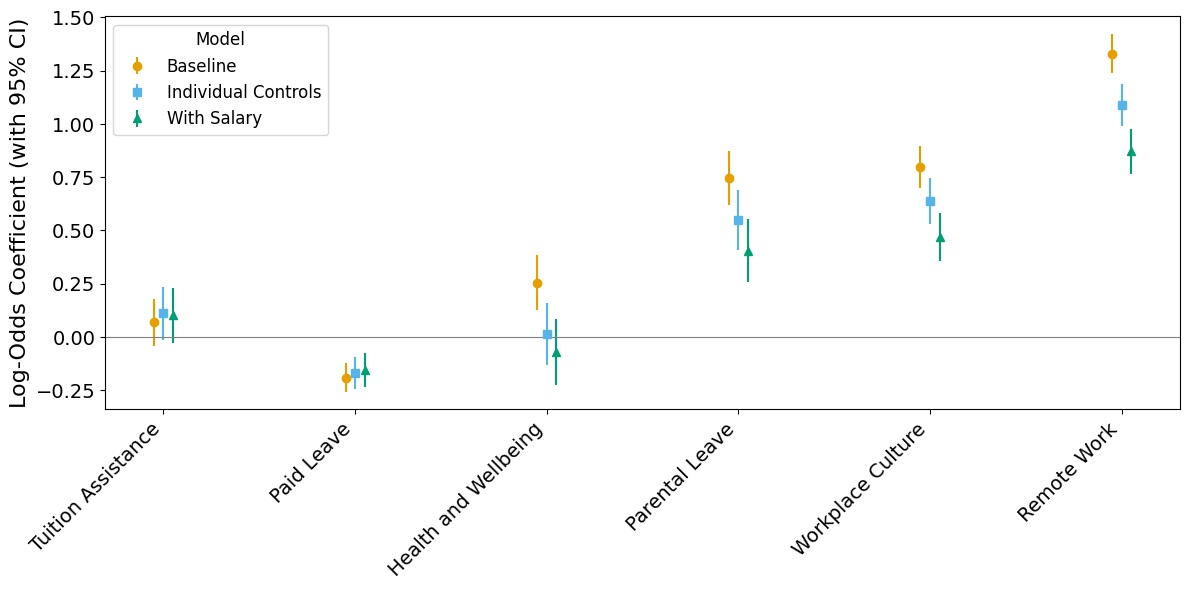

In [55]:
import matplotlib.pyplot as plt
import numpy as np

# Define colors for each model
colors = ['#E69F00', '#56B4E9', '#009E73', '#CC79A7']
# Calculate the 95% confidence intervals
industry_df['Lower_CI'] = industry_df['Coefficient'] - 1.96 * industry_df['Error']
industry_df['Upper_CI'] = industry_df['Coefficient'] + 1.96 * industry_df['Error']

# Plotting
fig, ax = plt.subplots(figsize=(12, 6))

# benefits = benefits
model_iterations = industry_df['Model Iteration'].unique()
markers = ['o', 's', '^']  # Different markers for model iterations
positions = []
current_pos = 0

# Store legend handles and labels to avoid duplicates
handles, labels = [], []

for benefit in benefits4:
    benefit_data = industry_df[industry_df['Label'] == benefit]
    benefit_positions = []
    for i, model in enumerate(model_iterations):
        model_data = benefit_data[benefit_data['Model Iteration'] == model]
        if not model_data.empty:
            pos = current_pos + i * 0.2  # Adjust spacing between model_iterations within the same benefit
            handle = ax.errorbar(
                pos, model_data['Coefficient'].values, 
                yerr=[model_data['Coefficient'].values - model_data['Lower_CI'].values, 
                      model_data['Upper_CI'].values - model_data['Coefficient'].values], 
                fmt=markers[i], color=colors[i], label=model if benefit == benefits4[0] else ""
            )
            benefit_positions.append(pos)
            if benefit == benefits4[0]:  # Add handles and labels only for the first benefit to avoid duplicates
                handles.append(handle)
                labels.append(model)
            if not model_data['Converged'].values[0]:  # Assuming Converged is boolean
                ax.plot(pos, model_data['Coefficient'].values[0], 'rx', markersize=12, label='Did Not Converge')
        
    positions.extend(benefit_positions)
    current_pos += len(model_iterations) + 1  # Add more space between different benefits

# Customize plot
benefit_ticks = [(positions[i * len(model_iterations)] + positions[(i + 1) * len(model_iterations) - 1]) / 2 for i in range(len(benefits4))]
ax.set_xticks(benefit_ticks, labels = benefits4_labels)
ax.tick_params(axis='y', labelsize=14)
ax.set_xticklabels(benefits4_labels, rotation=45, fontsize = 14, ha='right')
# ax.set_title('AI Skill Coefficients by benefit and Occupation')
ax.set_xlabel(None)
ax.set_ylabel('Log-Odds Coefficient (with 95% CI)', fontsize=16)
ax.axhline(0, color='grey', linewidth=0.8)
ax.legend(handles, labels, title='Model', bbox_to_anchor=(0, 1), loc = 'upper left', fontsize = 12, title_fontsize = 12)
# ax.axhline(average_coefficient, color='black', linestyle='--', linewidth=1, label='Average Coefficient')
# plt.title('Models with Industry and Year Fixed Effects', fontsize = 16)
plt.tight_layout()
plt.savefig('../figures/model_coefficients_plot_industry_converged.png')
plt.show()


# Tables

In [67]:
from collections import defaultdict

In [84]:
fixed_effects_variables = [year, industry]

fixed_effects_var_dict = {var: list(even_sample[var].unique()) for var in fixed_effects_variables}
cat_var_dict = {}

for category, values in fixed_effects_var_dict.items():
    # category_label = category.split('_')[0]  # Get the label part of the category (e.g., 'STATE' from 'STATE_NAME')
    for value in values:
        cat_var_dict[value] = category
cat_var_dict
fixed_effects_categories = list(fixed_effects_var_dict.values())
fixed_effects_categories = [item for sublist in fixed_effects_categories for item in sublist]

In [85]:
fixed_effects_categories

[np.int32(2022),
 np.int32(2024),
 np.int32(2021),
 np.int32(2023),
 np.int32(2019),
 np.int32(2020),
 np.int32(2018),
 'Administrative and Support and Waste Management and Remediation Services',
 'Retail Trade',
 'Information',
 'Professional, Scientific, and Technical Services',
 'Finance and Insurance',
 'Unclassified Industry',
 'Real Estate and Rental and Leasing',
 'Manufacturing',
 'Other Services (except Public Administration)',
 'Public Administration',
 'Educational Services',
 'Health Care and Social Assistance',
 'Transportation and Warehousing',
 'Construction',
 'Other',
 'Utilities',
 'Wholesale Trade',
 'Accommodation and Food Services',
 'Arts, Entertainment, and Recreation']

In [86]:
model_fixed_effects_dict

NameError: name 'model_fixed_effects_dict' is not defined

In [92]:
def get_summary_table(models, export_name = 'table.tex'):
    """
    Generate a LaTeX table for a list of models with an indication of fixed effects variables.

    Parameters:
    - models: list of fitted model objects.
    - fixed_effects_variables: list of fixed effects variables.
    - filename: name of the output LaTeX file.
    """   
    # Assuming model1 and model2 are your fitted model objects
    # Create the Stargazer object with the models
    stargazer = Stargazer(models)
    # List of fixed effects variables
    # Automatically determine covariates to include (excluding fixed effects)
    
    cov_names = stargazer.cov_names
    if 'AI ROLE' in cov_names:
        cov_names.remove('AI ROLE')
        cov_names.insert(0, 'AI ROLE')
    stargazer.cov_names = cov_names
    
    
    fixed_effects_list = [cat for cat in fixed_effects_categories if cat in stargazer.cov_names]
    covariates_to_include = [covariate for covariate in stargazer.cov_names if covariate not in fixed_effects_list]
    
    # Remove unwanted covariates from stargazer
    for covariate in fixed_effects_list:
        if covariate in stargazer.cov_names:
            stargazer.cov_names.remove(covariate)

    
    # Add custom line for each fixed effect variable
    # stargazer.add_line("Fixed Effects")
    model_fixed_effects_dict = defaultdict(list)
    for i, model in enumerate(models): 
        model_fixed_effects_dict[i] = list(set([value for key, value in cat_var_dict.items() if key in model.model.exog_names]))
        
    fixed_effects_names = {'STATE_NAME': 'State',  'NAICS_2022_2_NAME': 'Industry', 'YEAR': 'Year', 'SOC_2021_2_NAME': 'Occupation'}    
    
    stargazer.add_line("\\textbf{Fixed Effects}", [""] * len(models))

    for variable in fixed_effects_variables:
        # fixed_effects = [value for key: value in cat_var_dict if key in stargazer.cov_names]
        variable_name = fixed_effects_names[variable]
        inclusion_list = ['Yes' if variable in model_fixed_effects_dict[model] else 'Yes' for model in model_fixed_effects_dict]
        stargazer.add_line(f"{variable_name}", inclusion_list)

    # Customize the Stargazer table (optional)
    # stargazer.title("Regression Results")
    # stargazer.custom_columns([f"Model {i+1}" for i in range(len(models))], [1] * len(models))

    stargazer.significance_levels([0.1, 0.05, 0.01])
    # stargazer.add_line("Observations", [len(model.model.endog) for model in models])

    # Render LaTeX table
    latex_table = stargazer.render_latex()
    print(latex_table)
    # export latex table
    with open(f'../exports/tables/{export_name}', 'w') as file:
        file.write(latex_table)
    
    display(HTML(stargazer.render_html()))
    # Print the LaTeX table to verify

In [93]:
get_summary_table(model_progression, export_name = 'job_level_model.tex')

\begin{table}[!htbp] \centering
\begin{tabular}{@{\extracolsep{5pt}}lccc}
\\[-1.8ex]\hline
\hline \\[-1.8ex]
& \multicolumn{3}{c}{\textit{Dependent variable: EDU_ASSISTANCE}} \
\cr \cline{2-4}
\\[-1.8ex] & (1) & (2) & (3) \\
\hline \\[-1.8ex]
 AI ROLE & 0.069$^{}$ & 0.111$^{*}$ & 0.101$^{}$ \\
& (0.056) & (0.063) & (0.067) \\
 0 years & & 0.004$^{}$ & 0.007$^{}$ \\
& & (0.167) & (0.167) \\
 1-2 years & & -0.158$^{**}$ & -0.158$^{**}$ \\
& & (0.077) & (0.077) \\
 11-20 years & & -0.140$^{}$ & -0.157$^{}$ \\
& & (0.173) & (0.177) \\
 2019 & 0.079$^{}$ & 0.055$^{}$ & 0.054$^{}$ \\
& (0.211) & (0.212) & (0.212) \\
 2020 & -0.039$^{}$ & -0.072$^{}$ & -0.074$^{}$ \\
& (0.204) & (0.205) & (0.205) \\
 2021 & 0.423$^{**}$ & 0.356$^{**}$ & 0.354$^{**}$ \\
& (0.176) & (0.177) & (0.177) \\
 2022 & 0.641$^{***}$ & 0.604$^{***}$ & 0.600$^{***}$ \\
& (0.169) & (0.170) & (0.170) \\
 2023 & 0.892$^{***}$ & 0.874$^{***}$ & 0.868$^{***}$ \\
& (0.166) & (0.167) & (0.167) \\
 2024 & 0.903$^{***}$ & 0.888$^

In [89]:
model_progression = [models[0] for models in [benefit_models_industry, benefit_models_industry_2, benefit_models_industry_3]]

In [90]:
model_progression

In [91]:
from stargazer.stargazer import Stargazer
from IPython.core.display import HTML

In [62]:
stargazer = Stargazer(model_progression)
display(HTML(stargazer.render_html()))